In [1]:
import data_preparation
import models
import hydra 
from hydra import compose, initialize
import torch 
import matplotlib.pyplot as plt 
from tqdm import tqdm
import os
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [2]:
initialize(version_base=None, config_path="../config")
cfg = compose(config_name="train_general.yaml", overrides=['dataset=climsim_from_npy', 'model=squeezeformer', 'testing=ft'])
print(cfg.dataset)
print(cfg.model)

{'dataset_name': 'climsim_from_npy', 'input_dim': 94, 'output_dim': 98, 'levels': 45, 'normalize': True, 'normalize_targets': True, 'target_group': '${target_group}', 'data_dir': '/work/scratch-pw5/bradlesc/climsim/processed/group_by_months/', 'input_file': 'input.npy', 'target_file': 'target.npy', 'output_scale_file_path': '/home/users/bradlesc/projects/ClimSim/preprocessing/normalizations/outputs/output_scale.nc', 'v1_targets': ['ptend_t', 'ptend_q0001', 'cam_out_NETSW', 'cam_out_FLWDS', 'cam_out_PRECSC', 'cam_out_PRECC', 'cam_out_SOLS', 'cam_out_SOLL', 'cam_out_SOLSD', 'cam_out_SOLLD'], 'split': {'train': 0.8, 'val': 0.1, 'test': 0.1}, 'dataset_testing_sample_rates': {'quick': 10000, 'reduced': 100, 'full': 7}, 'group_method': 'group_by_months', 'group_by_months': {'num_groups': 4, 'target_group': '${target_group}', 'groups': {'DJF': [], 'MAM': [], 'JJA': [], 'SON': []}, 'test_group': {'SON': None}, 'val_group': {'SON': None}}, 'general_dataset_config': {'num_workers': '${testing.nu

# Performance Analysis 003

This is a notebook exploring models that have been trained on normalised targets, trying to understand how this a. varies from previous and b. understand how these models compare 

In [3]:
def reshape_to_standard_format(x: np.ndarray) -> np.ndarray:
        """
        Reshapes the output to standard format (batch, variables) from (batch, levels, features)
        Args:
            x: (torch.Tensor) (batch, levels, features) output data from the model
        Returns:
            reshaped_x: (torch.Tensor) (batch, features) reshaped output data
        """

        first_two = x[:, :, 0:2].transpose(0, 2, 1).reshape(x.shape[0], -1)
        means_2_to_9 = x[:, :, 2:10].mean(axis=1)

        # concatenate once
        output = np.concatenate([first_two, means_2_to_9], axis=1)
        return output


In [4]:
def unnormalize(data, normalisation_stats):

    return data * (normalisation_stats['target_max'] - normalisation_stats['target_min']) + normalisation_stats['target_mean']

def normalize(data, normalisation_stats):
    return (data - normalisation_stats['target_mean']) / (normalisation_stats['target_max'] - normalisation_stats['target_min'])

In [5]:
# Getting normalisation stats
cfg.dataset.group_by_months.target_group = "MAM"
mam_trainset = data_preparation.ClimSimNpyDataset(
    cfg.dataset,
    cfg.testing.dataset_testing_type,
    "train",
    normalisation_stats=None,
    model=None,
    seed=0,
)

mam_trained_normalisation_stats = mam_trainset.normalisation_stats

logging.info("---")

cfg.dataset.group_by_months.target_group = "SON"
son_trainset = data_preparation.ClimSimNpyDataset(
    cfg.dataset,
    cfg.testing.dataset_testing_type,
    "train",
    normalisation_stats=None,
    model=None,
    seed=0,
)

son_trained_normalisation_stats = son_trainset.normalisation_stats

2026-01-08 10:31:28,966 - INFO - Building dataset for group: MAM
2026-01-08 10:31:28,966 - INFO - Using sample rate directory: sample_rate_7
2026-01-08 10:31:34,309 - INFO - Loaded input shape: (2907264, 94)
2026-01-08 10:31:34,310 - INFO - Loaded target shape: (2907264, 98)
2026-01-08 10:31:34,358 - INFO - Using: train with 2325811 samples
2026-01-08 10:31:49,990 - INFO - Calculating normalization statistics from data.
2026-01-08 10:32:07,103 - INFO - Calculating normalization statistics from data for targets.
2026-01-08 10:32:18,200 - INFO - Data is in MLP format; no conversion needed.
2026-01-08 10:32:18,201 - INFO - ---
2026-01-08 10:32:18,201 - INFO - Building dataset for group: SON
2026-01-08 10:32:18,202 - INFO - Using sample rate directory: sample_rate_7
2026-01-08 10:32:23,377 - INFO - Loaded input shape: (2875392, 94)
2026-01-08 10:32:23,378 - INFO - Loaded target shape: (2875392, 98)
2026-01-08 10:32:23,440 - INFO - Using: train with 2300313 samples
2026-01-08 10:32:41,402 -

In [6]:
mam_trainset_input = mam_trainset.input.numpy()
son_trainset_input = son_trainset.input.numpy()

In [7]:
path_to_data = '/work/scratch-pw5/bradlesc/climsim/temp/p2.1.4.9_analysis/norm_outputs_001/'
!ls {path_to_data}

train_group_MAM  train_group_SON


In [8]:

# SON trained model

#   SON test set
son_trained_son_input = reshape_to_standard_format(np.load(os.path.join(path_to_data, 'train_group_SON', 'SON_test_inputs.npy')))
son_trained_son_preds = np.load(os.path.join(path_to_data, 'train_group_SON', 'SON_test_outputs.npy'))
son_trained_son_targs = np.load(os.path.join(path_to_data, 'train_group_SON', 'SON_test_targets.npy'))
# son_trained_son_abs_error = np.abs(son_trained_son_preds - son_trained_son_targs)

#   MAM test set
son_trained_mam_input = reshape_to_standard_format(np.load(os.path.join(path_to_data, 'train_group_SON', 'MAM_test_inputs.npy')))
son_trained_mam_preds = np.load(os.path.join(path_to_data, 'train_group_SON', 'MAM_test_outputs.npy'))
son_trained_mam_targs = np.load(os.path.join(path_to_data, 'train_group_SON', 'MAM_test_targets.npy'))
# son_trained_mam_abs_error = np.abs(son_trained_mam_preds - son_trained_mam_targs)


# MAM trained model

#   SON test set
mam_trained_son_input = reshape_to_standard_format(np.load(os.path.join(path_to_data, 'train_group_MAM', 'SON_test_inputs.npy')))
mam_trained_son_preds = np.load(os.path.join(path_to_data, 'train_group_MAM', 'SON_test_outputs.npy'))
mam_trained_son_targs = np.load(os.path.join(path_to_data, 'train_group_MAM', 'SON_test_targets.npy'))
# mam_trained_son_abs_error = np.abs(mam_trained_son_preds - mam_trained_son_targs)

#   MAM test set
mam_trained_mam_input = reshape_to_standard_format(np.load(os.path.join(path_to_data, 'train_group_MAM', 'MAM_test_inputs.npy')))
mam_trained_mam_preds = np.load(os.path.join(path_to_data, 'train_group_MAM', 'MAM_test_outputs.npy'))
mam_trained_mam_targs = np.load(os.path.join(path_to_data, 'train_group_MAM', 'MAM_test_targets.npy'))
# mam_trained_mam_abs_error = np.abs(mam_trained_mam_preds - mam_trained_mam_targs)


#   JJA test set
mam_trained_jja_input = reshape_to_standard_format(np.load(os.path.join(path_to_data, 'train_group_MAM', 'JJA_test_inputs.npy')))
mam_trained_jja_preds = np.load(os.path.join(path_to_data, 'train_group_MAM', 'JJA_test_outputs.npy'))
mam_trained_jja_targs = np.load(os.path.join(path_to_data, 'train_group_MAM', 'JJA_test_targets.npy'))
# mam_trained_jja_abs_error = np.abs(mam_trained_jja_preds - mam_trained_jja_targs)

nvar = son_trained_son_preds.shape[1]

In [9]:
son_trained_son_targs_norm = normalize(son_trained_son_targs, son_trained_normalisation_stats)
mam_trained_son_targs_norm = normalize(mam_trained_son_targs, mam_trained_normalisation_stats)

son_trained_son_preds_unnorm = unnormalize(son_trained_son_preds, son_trained_normalisation_stats)
mam_trained_son_preds_unnorm = unnormalize(mam_trained_son_preds, mam_trained_normalisation_stats)

In [10]:
son_trained_son_MSE = ((unnormalize(son_trained_son_preds, son_trained_normalisation_stats) - son_trained_son_targs) ** 2).mean()
mam_trained_son_MSE = ((unnormalize(mam_trained_son_preds, mam_trained_normalisation_stats) - mam_trained_son_targs) ** 2).mean()

son_trained_mam_MSE = ((unnormalize(son_trained_mam_preds, son_trained_normalisation_stats) - son_trained_mam_targs) ** 2).mean()
mam_trained_mam_MSE = ((unnormalize(mam_trained_mam_preds, mam_trained_normalisation_stats) - mam_trained_mam_targs) ** 2).mean()


print("SON test set")
print("SON trained model on SON test set MSE:", son_trained_son_MSE)
print("MAM trained model on SON test set MSE:", mam_trained_son_MSE)
print("MAM test set")
print("SON trained model on MAM test set MSE:", son_trained_mam_MSE)
print("MAM trained model on MAM test set MSE:", mam_trained_mam_MSE)

SON test set
SON trained model on SON test set MSE: 15.027638
MAM trained model on SON test set MSE: 23.6074
MAM test set
SON trained model on MAM test set MSE: 25.114697
MAM trained model on MAM test set MSE: 15.333718


Ok sweet - so far so good, the results we expect are shown here with each model performing worse on its 'non-trained model' the high error is interesting! To see how these results compare to our other models, lets load these in and un-scale them

In [11]:
import xarray as xr

def undo_out_scale(data, path_to_out_scale='/home/users/bradlesc/projects/ClimSim/preprocessing/normalizations/outputs/output_scale.nc'):
    max_levels = 60
    min_levels = max_levels - 45
    out_scale = xr.open_dataset(path_to_out_scale)
    out_scale = out_scale[list(cfg.dataset.v1_targets)]
    out_scale = out_scale.sel(lev=slice(min_levels, max_levels))
    out_scale_array = out_scale.to_array()

    v_vectors = out_scale_array[0:2]

    v_scalars = out_scale_array[2:, 0]

    out_scale = np.concatenate(
        [v_vectors.values.flatten(), v_scalars.values.flatten()]
    )

    print(out_scale.shape)

    return data / out_scale

In [12]:
path_to_data = '/work/scratch-pw5/bradlesc/climsim/temp/p2.1.4.9_analysis/'
!ls {path_to_data}

#   SON test set
old_son_trained_son_input = reshape_to_standard_format(np.load(os.path.join(path_to_data, 'train_group_SON', 'SON_test_inputs.npy')))
old_son_trained_son_preds = np.load(os.path.join(path_to_data, 'train_group_SON', 'SON_test_outputs.npy'))
old_son_trained_son_targs = np.load(os.path.join(path_to_data, 'train_group_SON', 'SON_test_targets.npy'))
old_son_trained_abs_error = np.abs(old_son_trained_son_preds - old_son_trained_son_targs)

# MAM trained model

#   SON test set
old_mam_trained_son_input = reshape_to_standard_format(np.load(os.path.join(path_to_data, 'train_group_MAM', 'SON_test_inputs.npy')))
old_mam_trained_son_preds = np.load(os.path.join(path_to_data, 'train_group_MAM', 'SON_test_outputs.npy'))
old_mam_trained_son_targs = np.load(os.path.join(path_to_data, 'train_group_MAM', 'SON_test_targets.npy'))
old_mam_trained_abs_error = np.abs(old_mam_trained_son_preds - old_mam_trained_son_targs)

norm_outputs_001  train_group_MAM  train_group_SON


In [13]:
old_son_trained_son_MSE = ((undo_out_scale(old_son_trained_son_preds) - undo_out_scale(old_son_trained_son_targs)) ** 2).mean()
old_mam_trained_son_MSE = ((undo_out_scale(old_mam_trained_son_preds) - undo_out_scale(old_mam_trained_son_targs)) ** 2).mean()

# son_trained_mam_MSE = ((unnormalize(son_trained_mam_preds, son_trained_normalisation_stats) - undo_out_scale(son_trained_mam_targs)) ** 2).mean()
# mam_trained_mam_MSE = ((unnormalize(mam_trained_mam_preds, mam_trained_normalisation_stats) - undo_out_scale(mam_trained_mam_targs)) ** 2).mean()

print("SON test set")
print("OLD SON trained model on SON test set MSE:", old_son_trained_son_MSE)
print("SON trained model on SON test set MSE:", son_trained_son_MSE)
print("OLD MAM trained model on SON test set MSE:", old_mam_trained_son_MSE)
print("MAM trained model on SON test set MSE:", mam_trained_son_MSE)
# print("MAM test set")
# print("SON trained model on MAM test set MSE:", son_trained_mam_MSE)
# print("MAM trained model on MAM test set MSE:", mam_trained_mam_MSE)

(98,)
(98,)
(98,)
(98,)
SON test set
OLD SON trained model on SON test set MSE: 17.94192506037046
SON trained model on SON test set MSE: 15.027638
OLD MAM trained model on SON test set MSE: 24.105695995221325
MAM trained model on SON test set MSE: 23.6074


SWEEEET - we have improvement! outscaling clearly was a bit susss and also we think we can do better! 

Great - next we move onto a deeper dive 

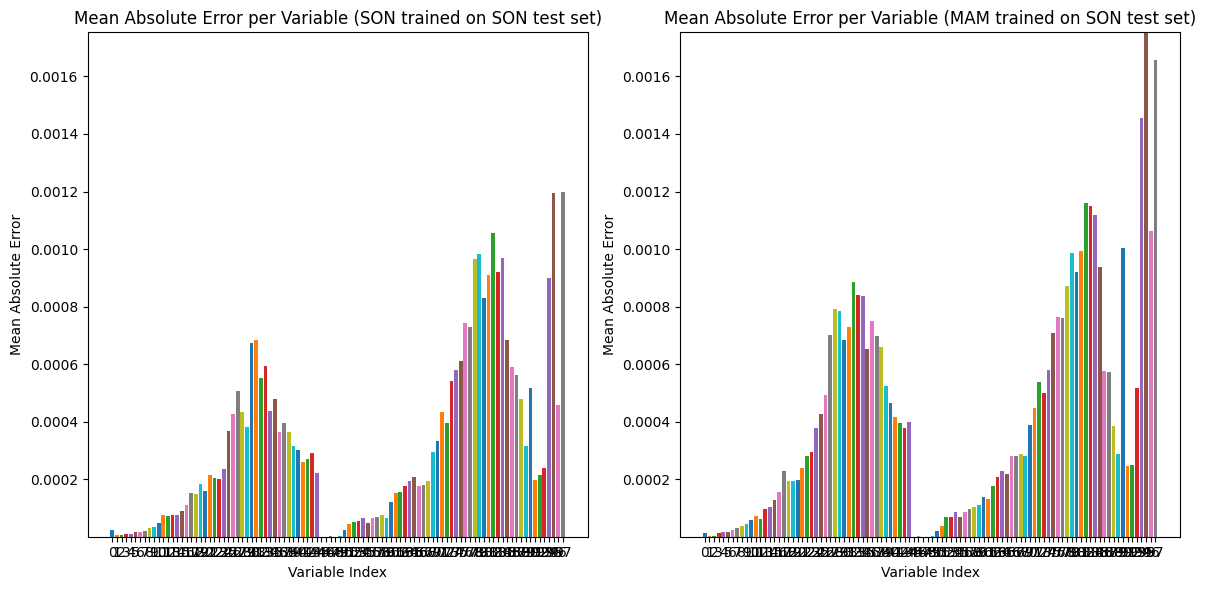

In [14]:
son_trained_son_MSE = ((son_trained_son_preds - normalize(son_trained_son_targs, son_trained_normalisation_stats)) ** 2).mean(axis=0)
mam_trained_son_MSE = ((mam_trained_son_preds - normalize(mam_trained_son_targs, mam_trained_normalisation_stats)) ** 2).mean(axis=0)


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
vmax = max(np.max(son_trained_son_MSE), np.max(mam_trained_son_MSE))
vmin = min(np.min(son_trained_son_MSE), np.min(mam_trained_son_MSE))
for i in range(nvar):
    axes[0].bar(i, son_trained_son_MSE[i], label=f'Var {i}')
    axes[1].bar(i, mam_trained_son_MSE[i], label=f'Var {i}')
axes[0].set_ylim([vmin, vmax])
axes[1].set_ylim([vmin, vmax])

axes[0].set_title('Mean Absolute Error per Variable (SON trained on SON test set)')
axes[0].set_xlabel('Variable Index')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_xticks(range(nvar))
axes[0].set_xticklabels([str(i) for i in range(nvar)])
# axes[0].legend()
axes[1].set_title('Mean Absolute Error per Variable (MAM trained on SON test set)')
axes[1].set_xlabel('Variable Index')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_xticks(range(nvar))
axes[1].set_xticklabels([str(i) for i in range(nvar)])
# axes[1].legend()
plt.tight_layout()
plt.show()

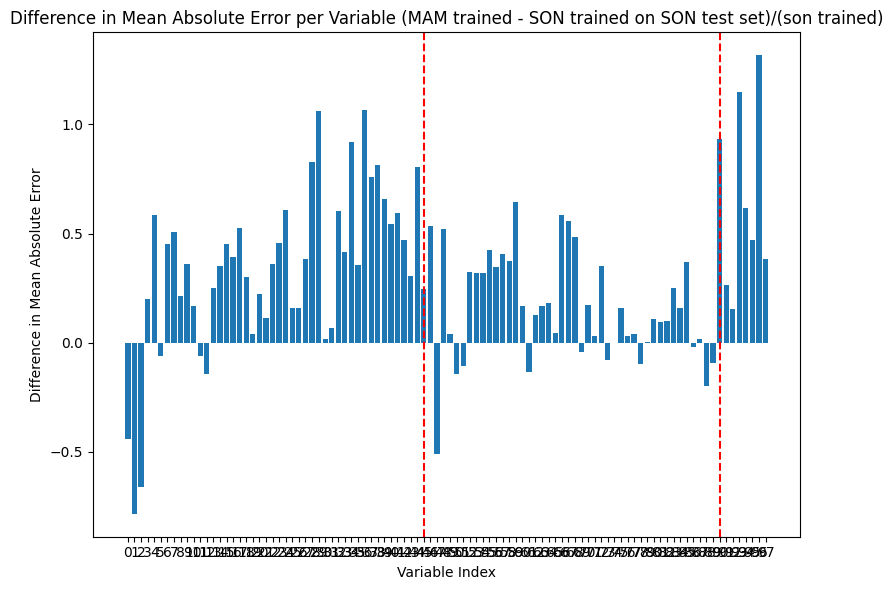

In [20]:
# differences = (mam_trained_son_abs_error.mean(axis=0) - son_trained_son_abs_error.mean(axis=0)) / son_trained_son_abs_error.mean(axis=0)
# norm_rmse_differences = (mam_trained_son_norm_RMSE - son_trained_son_norm_RMSE) / son_trained_son_norm_RMSE
differences = (mam_trained_son_MSE - son_trained_son_MSE) / son_trained_son_MSE
# vmax = np.max([differences, norm_rmse_differences])
# vmin = np.min([differences, norm_rmse_differences])
nvar = differences.shape[0]

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(range(nvar), differences)
# ax[0].set_ylim([vmin, vmax])
ax.set_title('Difference in Mean Absolute Error per Variable (MAM trained - SON trained on SON test set)/(son trained)')
ax.set_xlabel('Variable Index')
ax.set_ylabel('Difference in Mean Absolute Error')
ax.set_xticks(range(nvar))
ax.set_xticklabels([str(i) for i in range(nvar)])
ax.axvline(x=90, color='r', linestyle='--', label='95 Variables')
ax.axvline(x=45, color='r', linestyle='--', label='95 Variables')

plt.tight_layout()
plt.show()

Ok interesting - learning seems more fair now - as in sometimes different datasets does better. Biggest take away is majority of the difference in error comes from the tendancies and low altitude specific humidty

In [21]:
differences = (mam_trained_son_MSE - son_trained_son_MSE) / son_trained_son_MSE

sorted_error_differences_indeces = np.argsort(differences)[::-1]

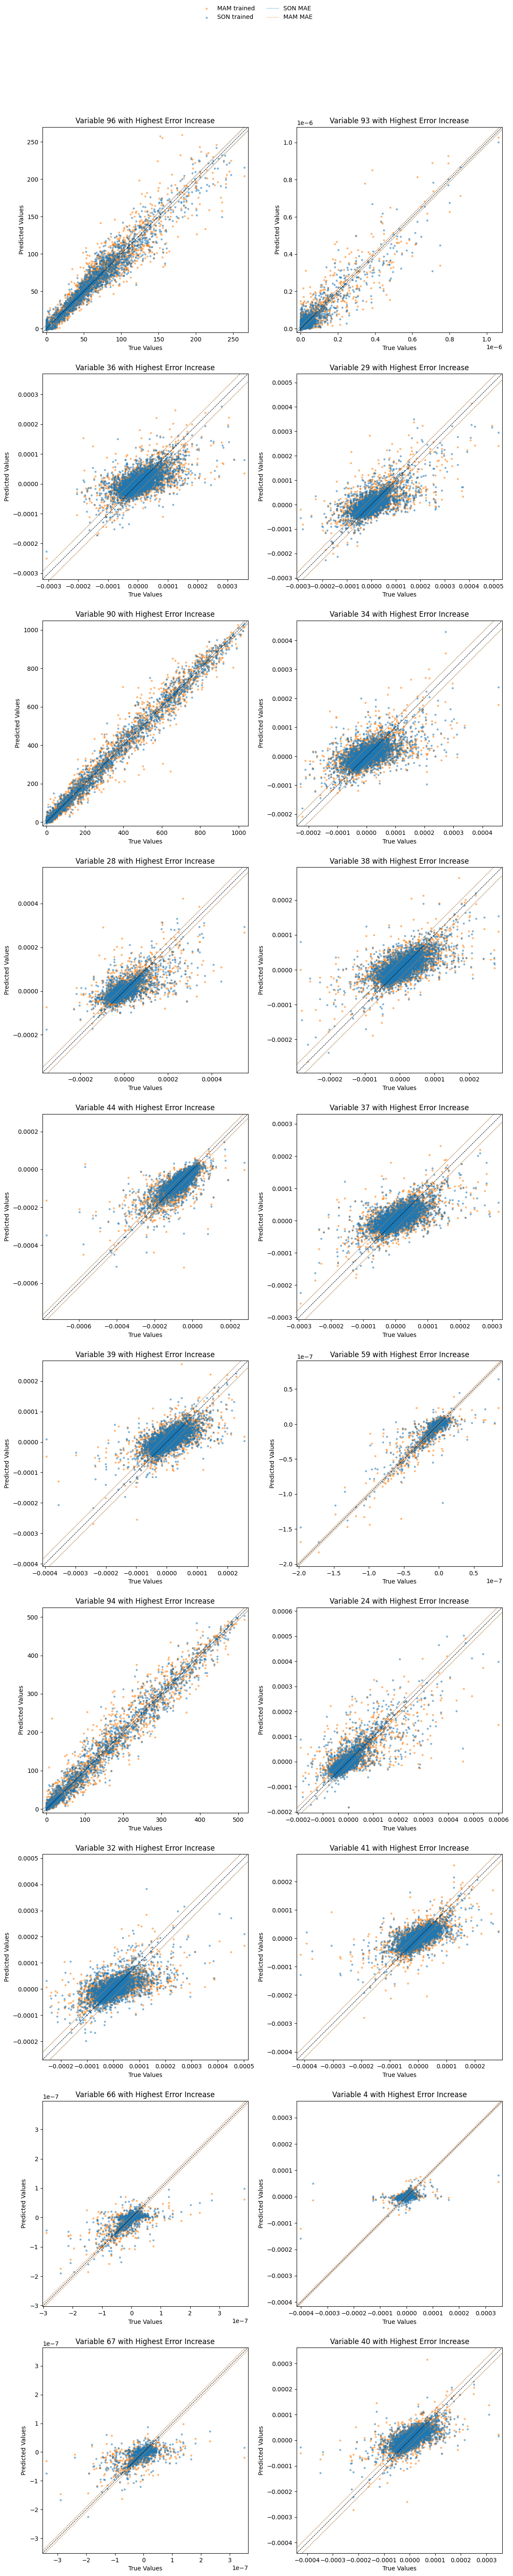

In [22]:
top_lot_to_show = 20
nrows = top_lot_to_show // 2
fig, axes = plt.subplots(nrows, 2, figsize=(12, 6 * nrows))  # smaller overall figure
axes = axes.ravel()

# Subsample size (adjust; 2000-5000 is usually responsive)
max_points = 4000

for i in range(top_lot_to_show):
    var_idx = int(sorted_error_differences_indeces[i])  # ensure plain int

    # select column for this variable
    son_preds = son_trained_son_preds_unnorm[:, var_idx]
    son_targs = son_trained_son_targs[:, var_idx]
    son_mae = np.abs(son_preds - son_targs).mean()
    mam_preds = mam_trained_son_preds_unnorm[:, var_idx]
    mam_targs = mam_trained_son_targs[:, var_idx]
    mam_mae = np.abs(mam_preds - mam_targs).mean()

    # subsample indices (same sample for both models to make comparison fair)
    n = len(son_preds)
    if n > max_points:
        rnd = np.random.default_rng(seed=42).choice(n, size=max_points, replace=False)
        son_x, son_y = son_targs[rnd], son_preds[rnd]
        mam_x, mam_y = mam_targs[rnd], mam_preds[rnd]
    else:
        son_x, son_y = son_targs, son_preds
        mam_x, mam_y = mam_targs, mam_preds

    ax = axes[i]
    # rasterized=True helps with vector outputs (PDF/SVG) and can speed rendering
    ax.scatter(mam_x, mam_y, alpha=0.45, s=6, label='MAM trained', rasterized=True, color='tab:orange')
    ax.scatter(son_x, son_y, alpha=0.45, s=6, label='SON trained', rasterized=True, color='tab:blue')

    vmin = min(son_x.min(), mam_x.min())
    vmax = max(son_x.max(), mam_x.max())
    pad = 0.02 * (vmax - vmin) if (vmax > vmin) else 0.1
    lo, hi = vmin - pad, vmax + pad
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)


    # MAE diagonals (SON)
    ax.plot([lo, hi], [lo + son_mae, hi + son_mae],
            color='tab:blue', ls=':', lw=1, label='SON MAE')
    ax.plot([lo, hi], [lo - son_mae, hi - son_mae],
            color='tab:blue', ls=':', lw=1)

    # MAE diagonals (MAM)
    ax.plot([lo, hi], [lo + mam_mae, hi + mam_mae],
            color='tab:orange', ls=':', lw=1, label='MAM MAE')
    ax.plot([lo, hi], [lo - mam_mae, hi - mam_mae],
        color='tab:orange', ls=':', lw=1)


    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'Variable {var_idx} with Highest Error Increase')
    ax.set_xlabel('True Values')
    ax.set_ylabel('Predicted Values')

# Legend only once (faster)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Hmm - ok ok, this is better for sure - no outputs that look like they havent learnt anything - but there is no clear divide between groups

In [23]:
def calculate_centrality_and_equality(trainset_input: np.ndarray, testset_input: np.ndarray):
    # Lets start with my 'explainability' idea
    nsamp_trainset, nvar_input = trainset_input.shape
    nsamp_testset, _ = testset_input.shape

    tol = 1e-8 # tolerance for float equality, adjust if needed

    # Pre-alloc output arrays
    percentage_within_array = np.empty((nsamp_testset, nvar_input), dtype=float)
    percentage_equal_array = np.empty((nsamp_testset, nvar_input), dtype=int)
    inv_nsamp_trainset = 1.0 / nsamp_trainset  # small micro-optimisation

    for j in range(nvar_input):
        col = trainset_input[:, j]
        sorted_col = np.sort(col)             # O(nmam log nmam) per column
        sample_vals = testset_input[:, j]  # shape (nson,)

        # counts of strictly less: index of first >= v  => number of elements < v
        left_idx = np.searchsorted(sorted_col, sample_vals, side='left')   # shape (nson,)
        # counts of strictly greater: nmam - index of last <= v => nmam - right_idx
        right_idx = np.searchsorted(sorted_col, sample_vals, side='right') # shape (nson,)
        number_less = left_idx
        number_greater = nsamp_trainset - right_idx

        # counts of "equal" within tolerance: count of values in [v-tol, v+tol]
        left_eq = np.searchsorted(sorted_col, sample_vals - tol, side='left')
        right_eq = np.searchsorted(sorted_col, sample_vals + tol, side='right')
        number_equal = (right_eq - left_eq).astype(int)

        # Print only where number_equal > 0 (vectorized find, then loop over those indices)
        eq_idxs = np.nonzero(number_equal > 0)[0]
        # for i in eq_idxs:
        #     val = sample_vals[i]
        #     print(f"JJA sample {i}, feature {j}, value {val:.6g} -> "
        #           f"{number_less[i]} less, {number_greater[i]} greater, "
        #           f"{number_equal[i]} equal in MAM (tol={tol}).")

        # percentage_within_array[:, j] = (number_less * inv_nmam) * (number_greater * inv_nmam)
        percentage_within_array[:, j] = abs((number_less * inv_nsamp_trainset) - 0.5) 
        percentage_equal_array[:, j] = number_equal
    return percentage_within_array, percentage_equal_array

mam_trained_son_percentage_within_array, mam_trained_son_percentage_equal_array = calculate_centrality_and_equality(mam_trainset_input, mam_trained_son_input)

In [19]:

def plot_centrality_with_error(abs_error: np.ndarray, percentage_within_array: np.ndarray, ranges: list=None, target_var: int=None):
    if target_var is None:
        error = abs_error.mean(axis=1)
    else:
        error = abs_error[:, target_var]
    # ranges = [[0, 0.05], [0.05, 0.1], [0.1, 0.15], [0.15, 0.2], [0.2, 0.25]]
    if ranges == None:
        ranges = [[0, 0.1], [0.1, 0.2], [0.2, 0.3], [0.3, 0.4], [0.4, 0.5]]

    sample_size = 10000
    rnd = np.random.default_rng(seed=42).choice(
        percentage_within_array.shape[0],
        size=sample_size,
        replace=False
    )
    sampled_centrality = percentage_within_array[rnd]
    nvar_input = sampled_centrality.shape[1]

    # Precompute mean errors for every (var, range) so we can set color normalization
    mean_errors = np.full((nvar_input, len(ranges)), np.nan)

    for var in range(nvar_input):
        var_errors = []
        var_centrality = percentage_within_array[:, var]
        for i, r in enumerate(ranges):
            idxs = np.where((var_centrality >= r[0]) & (var_centrality < r[1]))[0]
            if idxs.size == 0:
                continue
            mean_errors[var, i] = error[idxs].mean()
            var_errors.append(mean_errors[var, i])
        print(np.mean(np.array(var_errors)))
    # Determine colormap normalization from existing values
    valid_vals = mean_errors[~np.isnan(mean_errors)]
    if valid_vals.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        vmin, vmax = valid_vals.min(), valid_vals.max()

    cmap_name = "viridis"   # change if you'd like a different colormap
    cmap = get_cmap(cmap_name)
    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(30, 15))

    # Draw colored rectangles first (so violins overlay them)
    positions = np.arange(nvar_input) * 2
    rect_width = 0.8
    half_w = rect_width / 2.0
    alpha_rect = 0.7

    for var in range(nvar_input):
        center_x = positions[var] + 1.0  # centered around var*2 + 1
        left_x = center_x - half_w
        for i, r in enumerate(ranges):
            mean_e = mean_errors[var, i]
            if np.isnan(mean_e):
                # no data in this interval -> skip (or draw a neutral color if you prefer)
                continue
            y0, y1 = r[0], r[1]
            color = cmap(norm(mean_e))
            rect = Rectangle(
                (left_x, y0),           # (x,y) lower-left
                rect_width,             # width
                (y1 - y0),              # height
                facecolor=color,
                edgecolor=None,
                alpha=alpha_rect,
                zorder=1
            )
            ax.add_patch(rect)

    # Now draw violins on top
    parts = ax.violinplot(
        [sampled_centrality[:, var] for var in range(nvar_input)],
        positions=positions,
        widths=0.8,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    # Optional: style violins (light edge and fill)
    # for pc in parts['bodies']:
    #     pc.set_alpha(0.9)
    #     pc.set_edgecolor('black')
    #     pc.set_linewidth(0.3)

    # Add colorbar (create a ScalarMappable just for the colorbar)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(valid_vals)  # any non-empty array is fine; used to scale colorbar
    cbar = fig.colorbar(sm, ax=ax, pad=0.03)
    cbar.set_label('Mean absolute error')

    # Cosmetics
    ax.set_ylabel('Centrality (frac_less * frac_greater)')
    ax.set_xlabel('Input Variable Index')
    ax.set_title('Input Variable Centrality Density (Violin Plot) with Mean Error per Range')
    ax.set_xticks(positions)
    ax.set_xticklabels([str(i) for i in range(nvar_input)])
    ax.grid(True)

    # widen x-limits to make room for rectangles/annotations
    ax.set_xlim(positions.min() - 1, positions.max() + 2)

    plt.tight_layout()
    plt.show()



0.0076508097350597385
0.008024497609585523
0.00904456600546837
0.009249853622168302
0.00908261863514781
0.008487236872315406
0.008438904024660587
0.008490831591188908
0.008211992122232914
0.008188031241297722
0.008231645449995995
0.008252943586558103
0.008271567989140749
0.008278216794133186
0.008276612963527441
0.008288218453526498
0.008296432066708803
0.008304035011678933
0.008313629403710365
0.008324786461889744
0.00833302726969123
0.008353928755968808
0.008364524319767952
0.008365409169346093
0.008364273048937321
0.008374593406915664
0.008377549331635236
0.008380652591586112
0.008382202126085758
0.008386494312435388
0.008384000044316053
0.008383786026388406
0.008381842263042926
0.008387684542685746
0.00839892216026783
0.00841137981042266
0.008423241693526507
0.0084337062202394
0.00843937173485756
0.008438284322619439
0.008428458403795958
0.008414027001708745
0.008395297778770327
0.008384296856820583
0.008378715068101884
0.007330102380365133
0.007988966908305884
0.008307926543056964

/tmp/ipykernel_4011387/3884260340.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


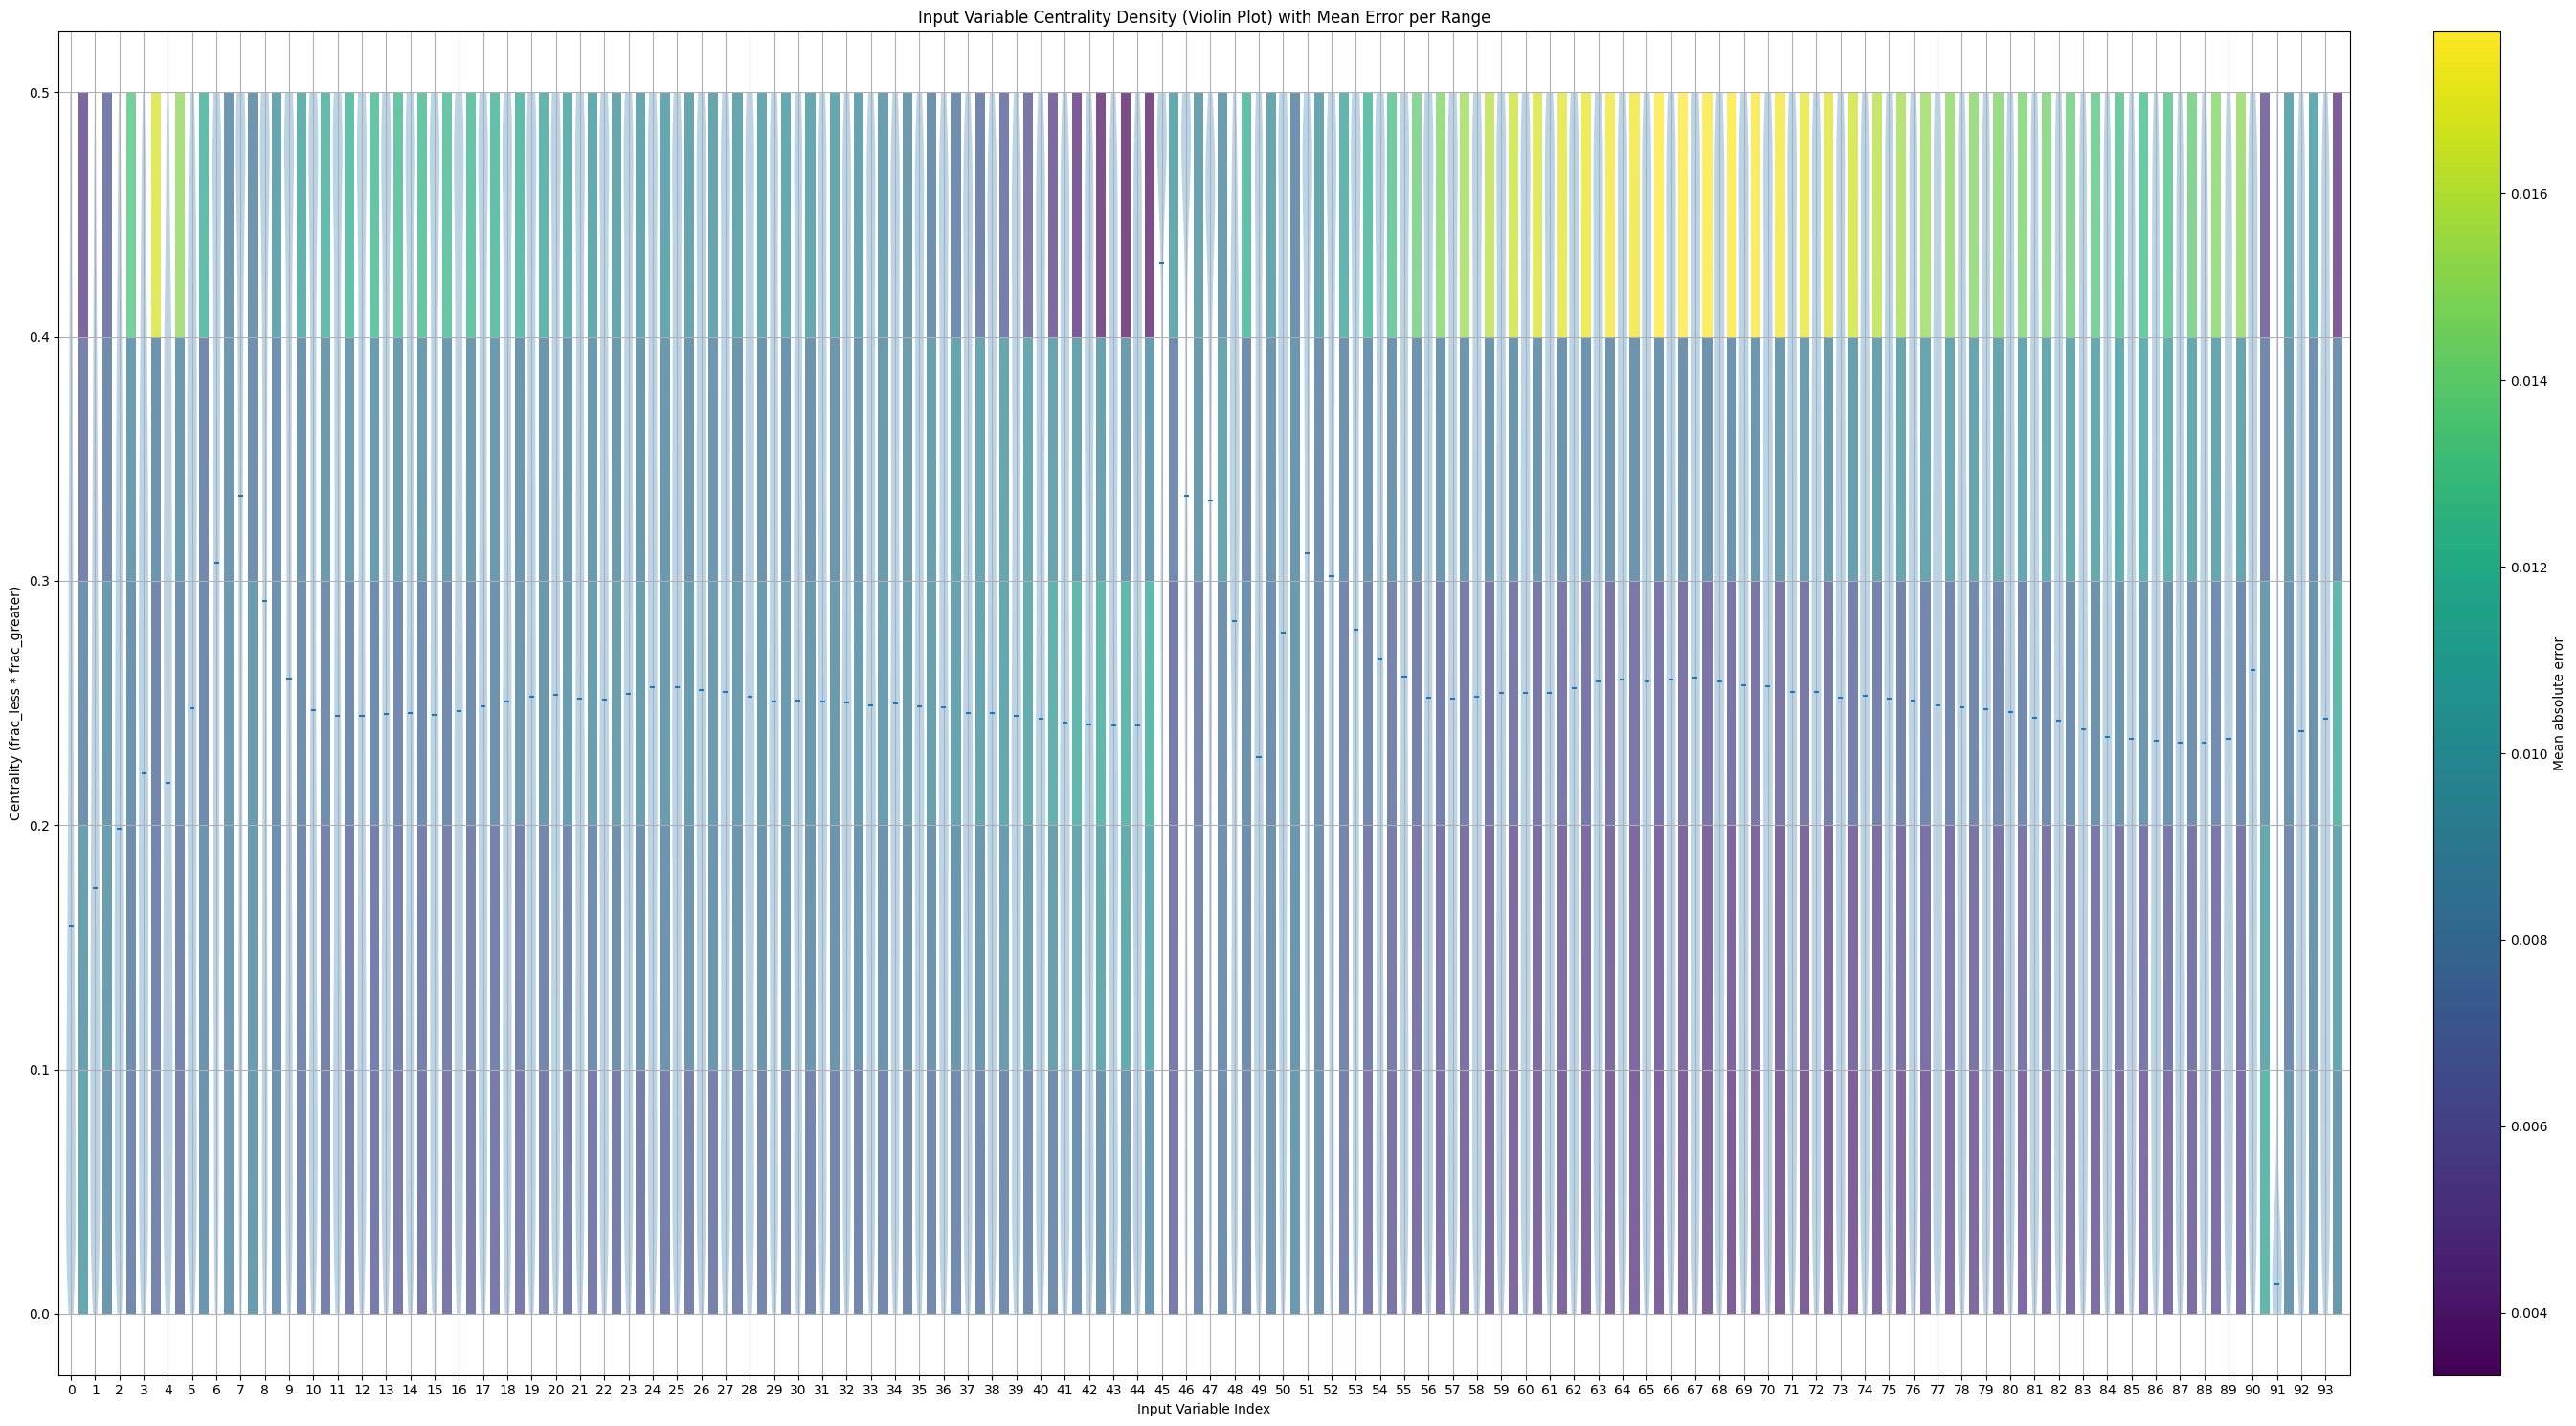

In [20]:
mam_trained_son_abs_error = np.abs(mam_trained_son_preds - mam_trained_son_targs_norm)


plot_centrality_with_error(mam_trained_son_abs_error, mam_trained_son_percentage_within_array, target_var=93)

In [21]:
son_trained_son_abs_error = np.abs(son_trained_son_preds - son_trained_son_targs_norm)
son_trained_son_percentage_within_array, son_trained_son_percentage_equal_array = calculate_centrality_and_equality(son_trainset_input, son_trained_son_input)


0.012102310732007026
0.012102651409804821
0.012103052251040936
0.012102427147328853
0.012091325409710408
0.012099337205290795
0.012100867182016372
0.012099242769181728
0.012098577991127967
0.012100278772413731
0.012103084847331047
0.012104566395282745
0.012103984132409096
0.012105006724596024
0.012103154323995113
0.012103844434022903
0.012102929875254631
0.01210267748683691
0.012102431058883667
0.012102536670863629
0.012102030031383038
0.01210270393639803
0.012102007679641247
0.012100906856358052
0.012100397609174252
0.012099855951964856
0.012100400030612945
0.012101293727755546
0.012099750339984894
0.012099000625312328
0.012099739350378513
0.012098423577845097
0.01210104487836361
0.012101037986576557
0.012104587256908416
0.012103293091058731
0.01210176683962345
0.012102553807199
0.01210400490090251
0.012105279695242643
0.012105792481452226
0.012102619744837284
0.012099713645875454
0.012097106408327818
0.0120992636308074
0.01210317425429821
0.01216436717659235
0.012094792164862155
0.01

/tmp/ipykernel_4011387/3884260340.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


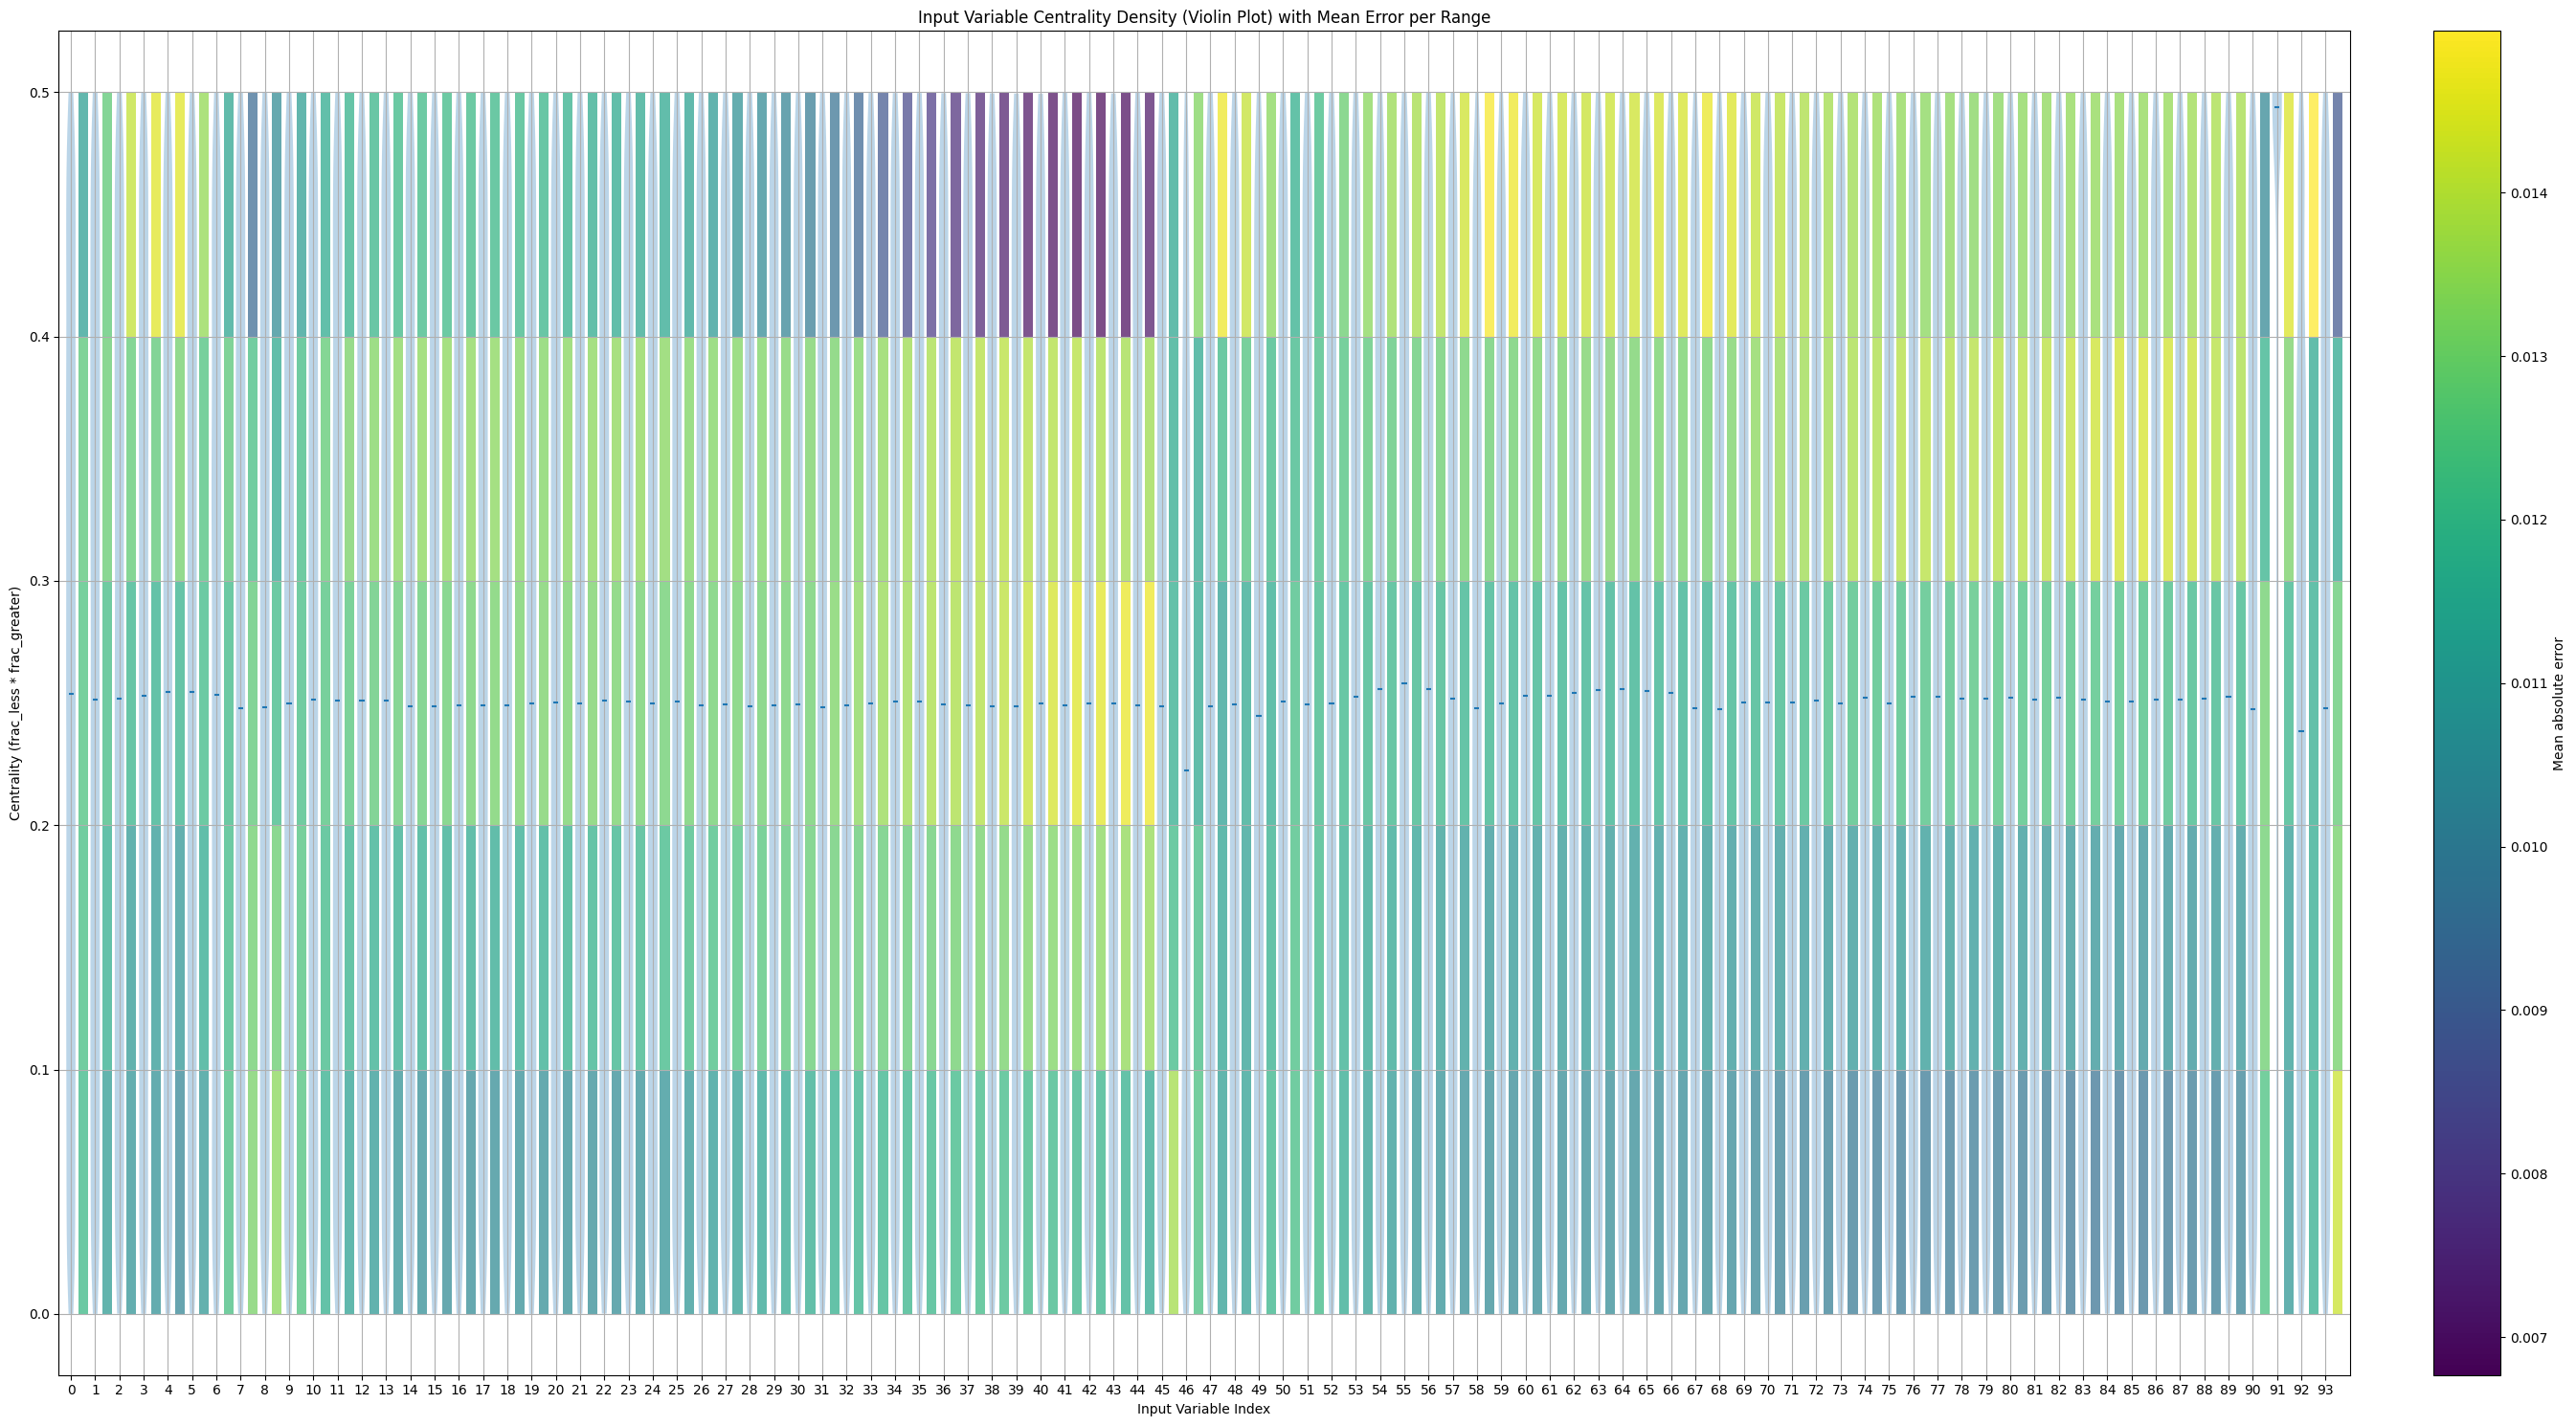

In [22]:
plot_centrality_with_error(son_trained_son_abs_error, son_trained_son_percentage_within_array, target_var=36)

0.004795772489160299
0.004972587618976831
0.005316618643701076
0.005348364636301994
0.005295684561133385
0.005144324526190758
0.005199420731514692
0.005205801501870155
0.005105204787105322
0.005103737022727728
0.00512257581576705
0.005128216464072466
0.005129568837583065
0.0051271610893309115
0.005118707753717899
0.005115509033203125
0.005114406161010265
0.005112338811159134
0.0051121460273861885
0.005112151149660349
0.005110154207795858
0.005115475971251726
0.005118795577436686
0.005118375364691019
0.005114403180778026
0.005116006452590227
0.00511875357478857
0.005121623445302248
0.005123804695904255
0.005123983044177294
0.005123325437307358
0.005123063270002603
0.005125749204307794
0.005130628310143948
0.005135626718401909
0.005141196958720684
0.005145197361707687
0.005147891491651535
0.005147678405046463
0.005145460087805987
0.005141007667407394
0.005134964920580387
0.005129744717851281
0.005126813007518649
0.00512563087977469
0.004795525316148996
0.005049721524119377
0.005176396947

/tmp/ipykernel_4011387/3884260340.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


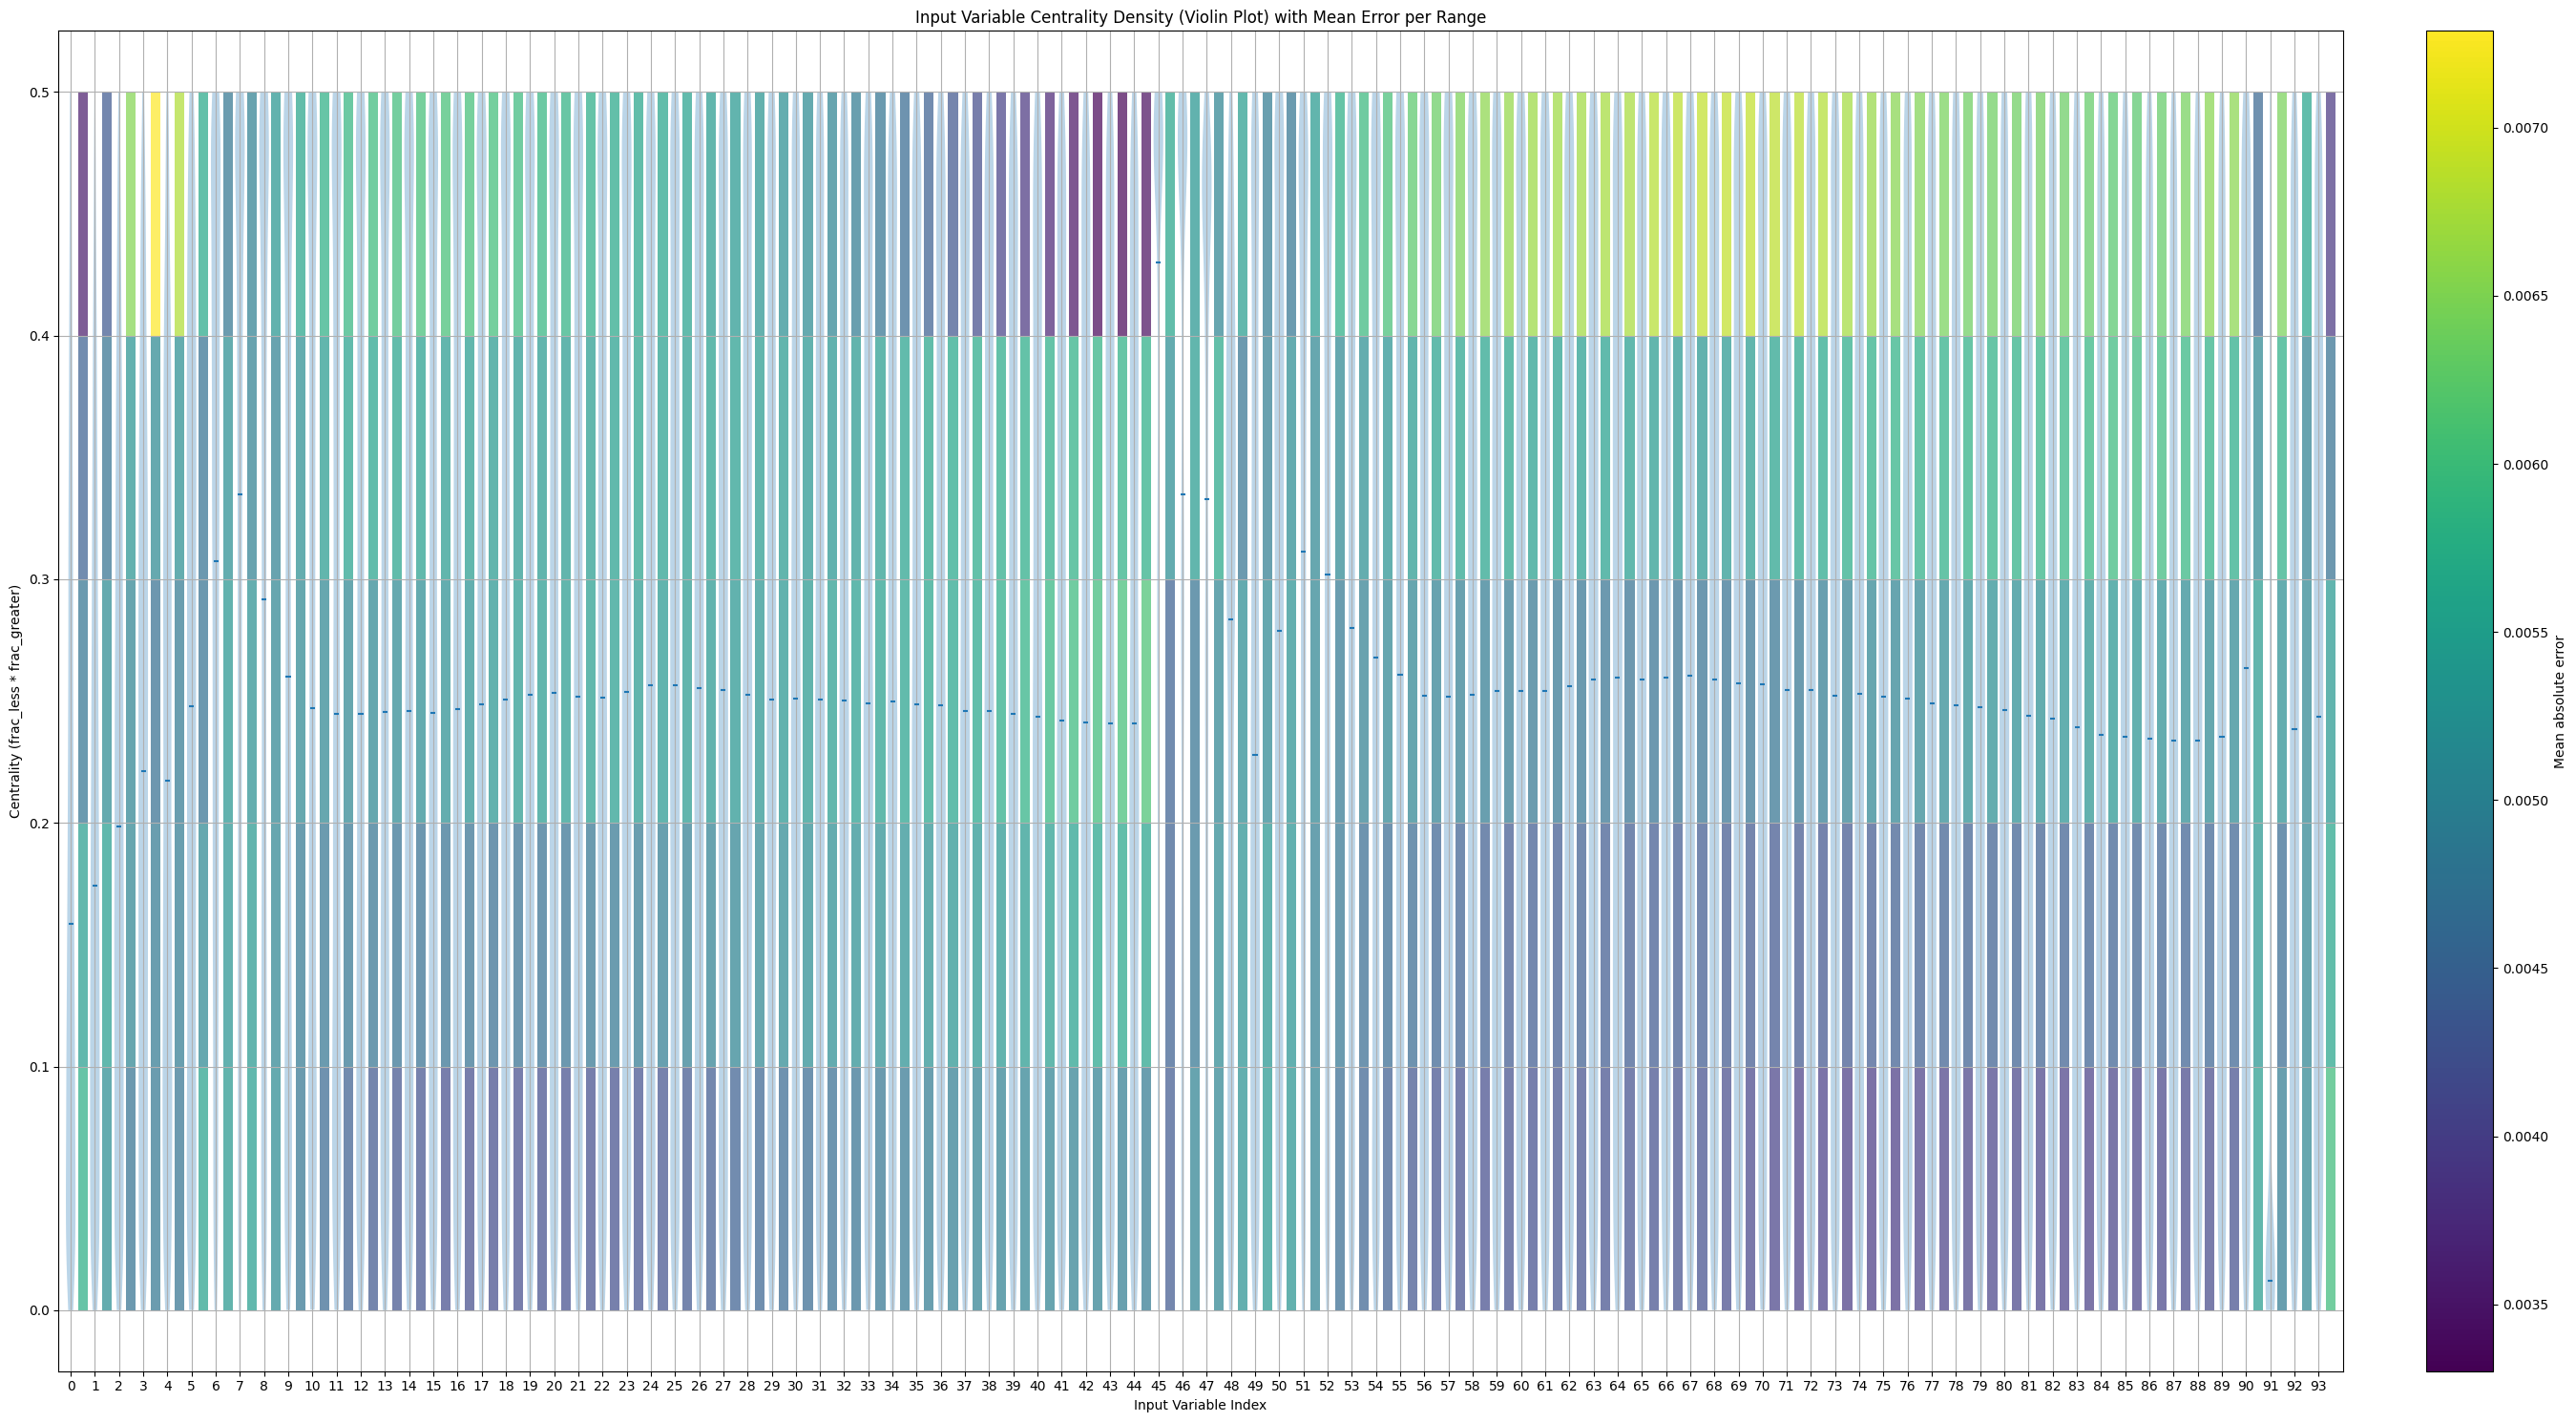

In [23]:
son_trained_son_abs_error = np.abs(son_trained_son_preds - son_trained_son_targs_norm)
error_difference = mam_trained_son_abs_error - son_trained_son_abs_error
plot_centrality_with_error(error_difference, mam_trained_son_percentage_within_array, target_var=36)


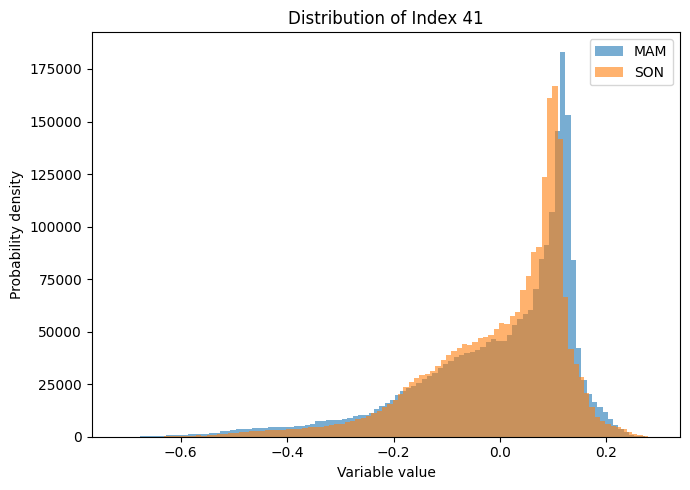

In [32]:
input_var_idx = 41

mam_vals = mam_trainset_input[:, input_var_idx]
son_vals = son_trainset_input[:, input_var_idx]

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(mam_vals, bins=100, density=False, alpha=0.6, label='MAM')
ax.hist(son_vals, bins=100, density=False, alpha=0.6, label='SON')
# ax.set_yscale('log')
plt.xlabel('Variable value')
plt.ylabel('Probability density')
plt.title(f'Distribution of Index {input_var_idx}')
plt.legend()

plt.tight_layout()
plt.show()


In [25]:
mam_dataset_raw = np.load("/work/scratch-pw5/bradlesc/climsim/processed/group_by_months/MAM/sample_rate_7/input.npy")
print(mam_dataset_raw.shape)

son_dataset_raw = np.load("/work/scratch-pw5/bradlesc/climsim/processed/group_by_months/SON/sample_rate_7/input.npy")
print(son_dataset_raw.shape)

(2907264, 94)
(2875392, 94)


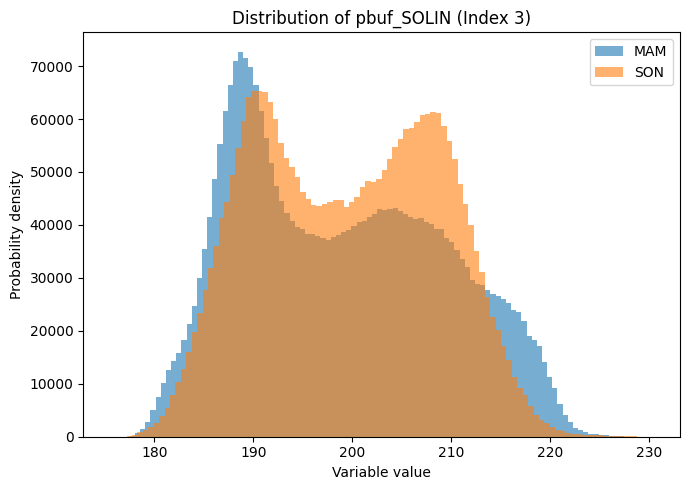

In [26]:
input_var_idx = 3  

mam_vals = mam_dataset_raw[:, input_var_idx]
son_vals = son_dataset_raw[:, input_var_idx]

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(mam_vals, bins=100, density=False, alpha=0.6, label='MAM')
ax.hist(son_vals, bins=100, density=False, alpha=0.6, label='SON')
# ax.set_yscale('log')
plt.xlabel('Variable value')
plt.ylabel('Probability density')
plt.title(f'Distribution of pbuf_SOLIN (Index {input_var_idx})')
plt.legend()

plt.tight_layout()
plt.show()

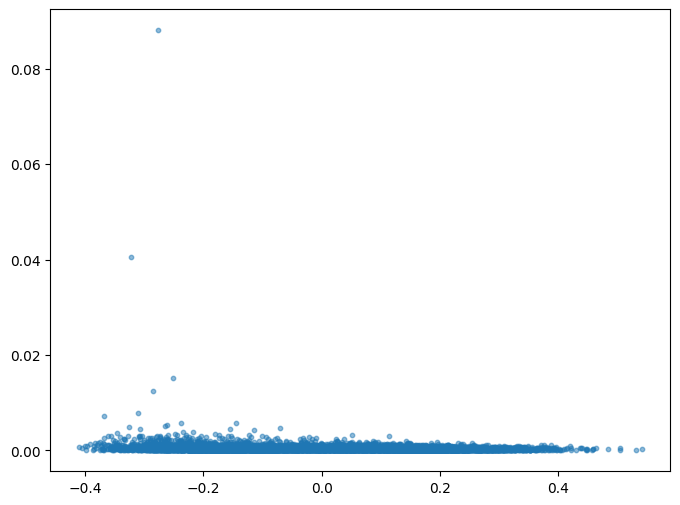

In [27]:
# mam_trained_son_abs_error
input_var_idx = 3
sample_size = 10000
rnd = np.random.default_rng(seed=42).choice(
    mam_trained_son_abs_error.shape[0],
    size=sample_size,
    replace=False
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    mam_trained_son_input[rnd, input_var_idx],
    mam_trained_son_abs_error[rnd, 46],
    alpha=0.5,
    s=10
)

So its like the input values are not out of distribution - but they are definately close to the edge and they seem to result in high error. My thought is high altitude specific humidity probably shouldnt really have an effect on these models - therefore spurious correlation comes to mind here?

In [28]:
son_trained_son_percentage_within_array.shape

(287540, 94)

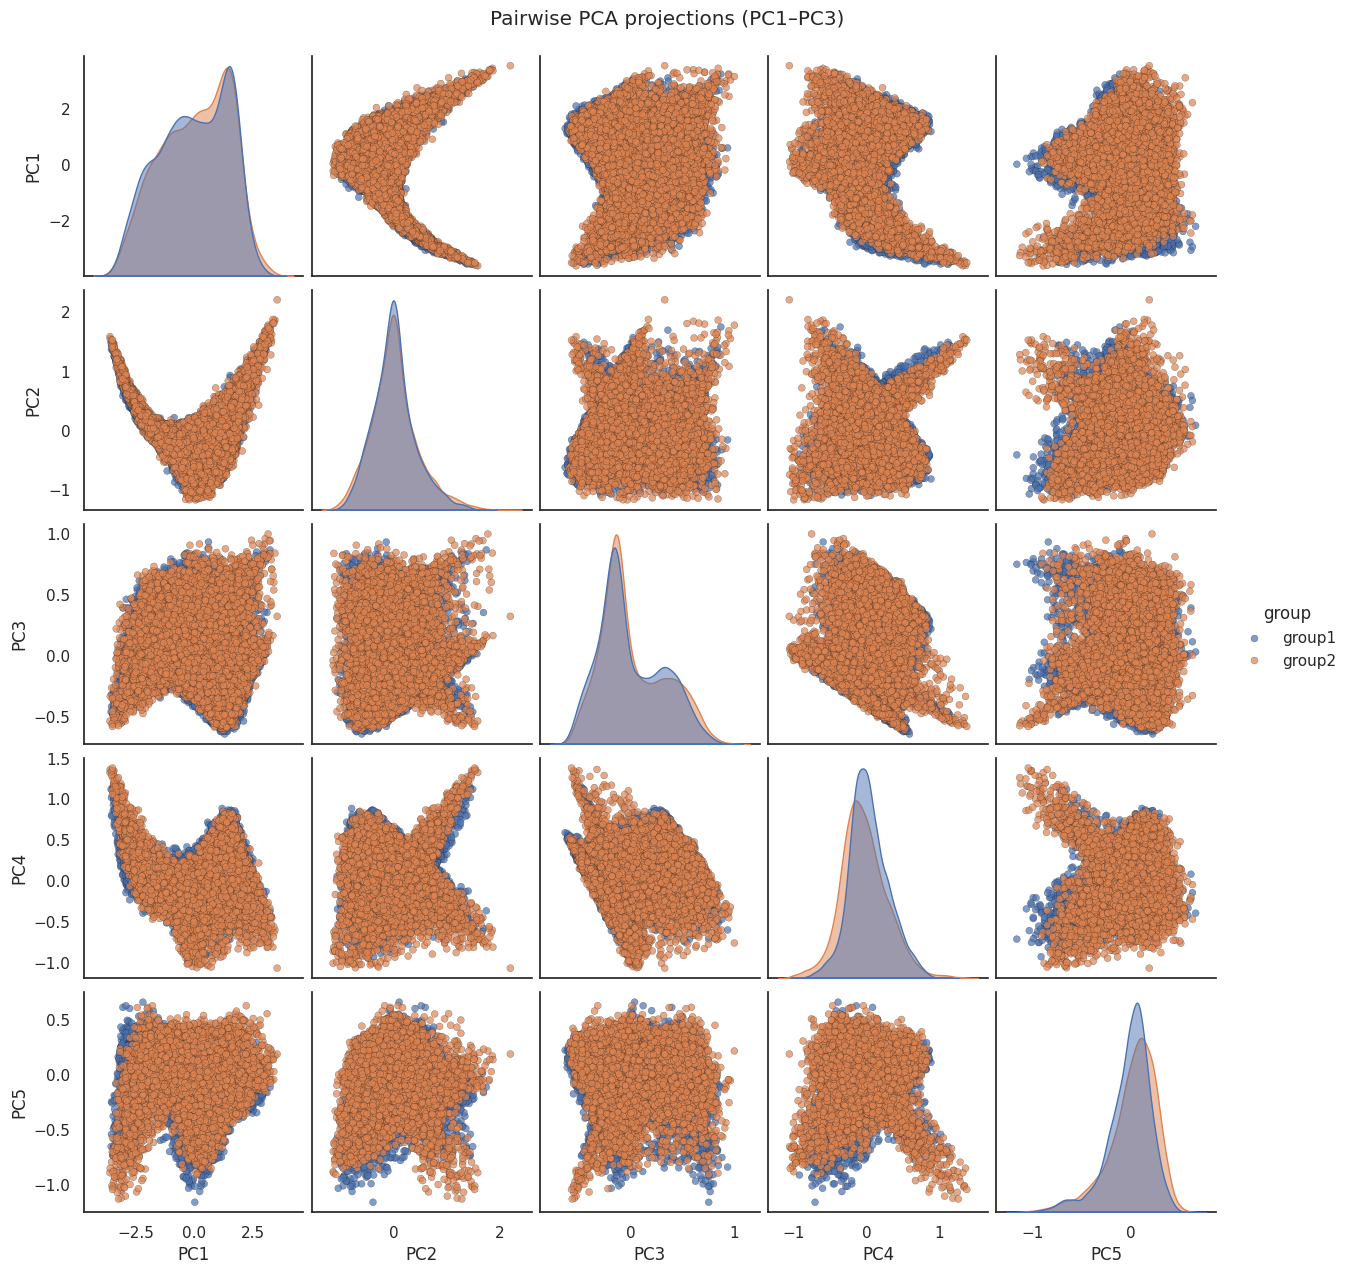

In [83]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
sample_size=10000

min_sample_size = min(mam_trained_mam_input.shape[0], mam_trained_son_input.shape[0])
rnd = np.random.default_rng(seed=42).choice(
    min_sample_size,
    size=sample_size,
    replace=False
)
X = np.concatenate([mam_trained_mam_input[rnd], mam_trained_son_input[rnd]], axis=0)



error = mam_trained_son_abs_error.mean(axis=1)[rnd]

# PCA
X_reduced = PCA(n_components=5).fit_transform(X)

# labels: first sample_size = group1, last sample_size = group2
labels = (['group1'] * sample_size) + (['group2'] * sample_size)

df = pd.DataFrame(
    X_reduced,
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
)
df['group'] = labels


import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white", context="notebook")

g = sns.pairplot(
    df,
    vars=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'],
    hue='group',
    diag_kind='kde',     # or 'hist'
    plot_kws=dict(
        s=25,
        alpha=0.7,
        edgecolor='k',
        linewidth=0.2
    ),
    diag_kws=dict(fill=True, alpha=0.5)
)

g.fig.suptitle("Pairwise PCA projections (PC1–PC3)", y=1.02)
plt.show()


ok - so 

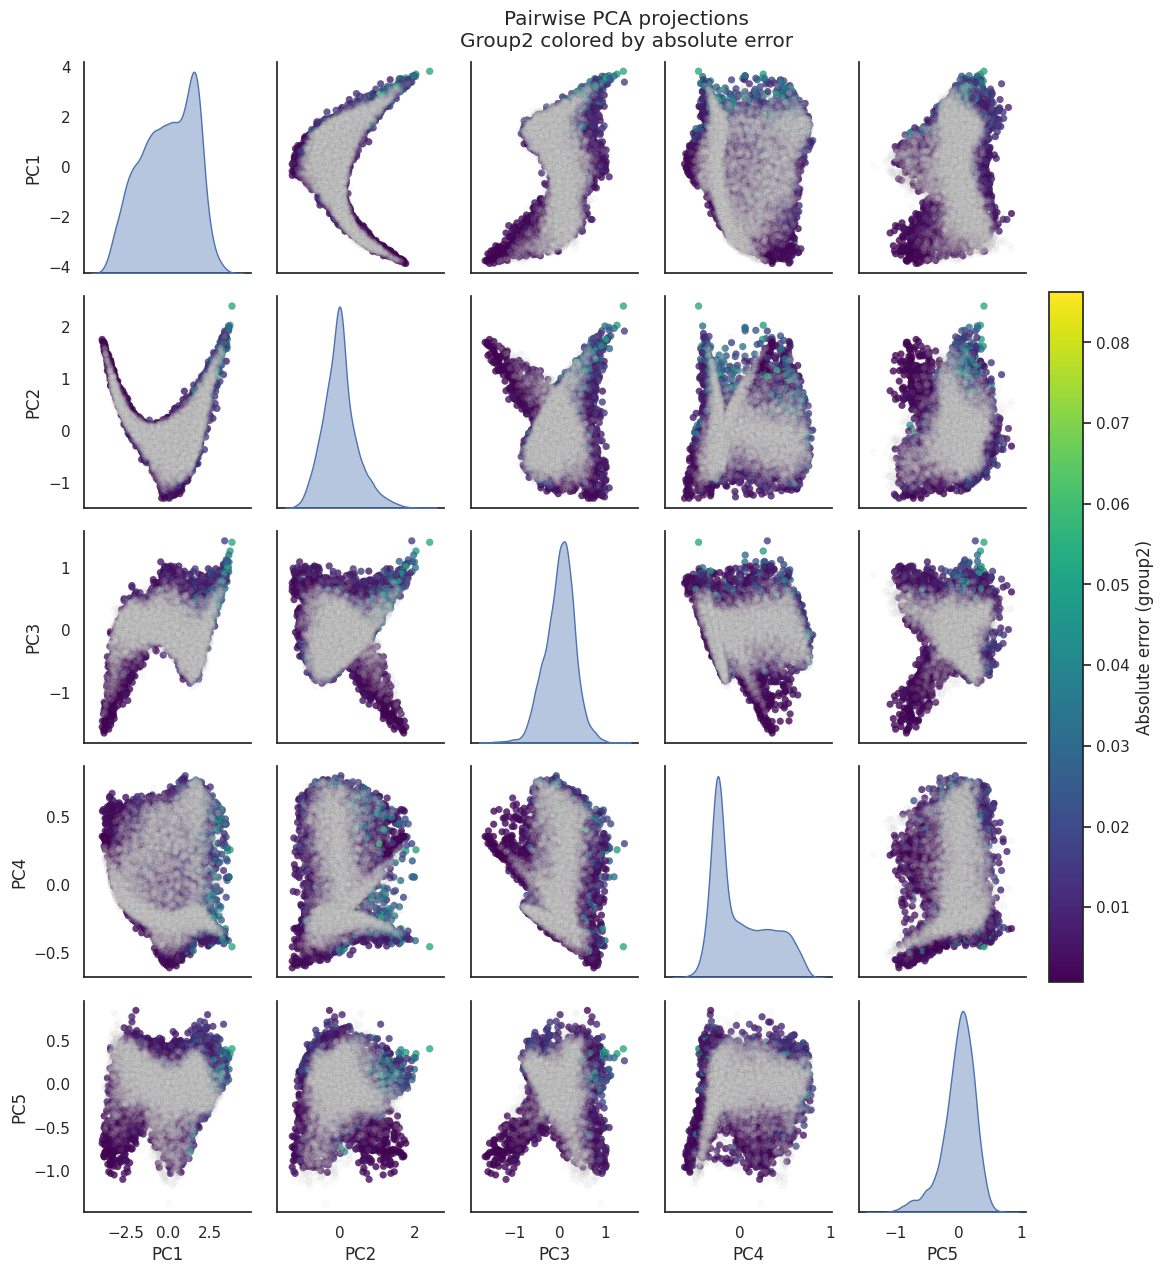

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Inputs ---
error = mam_trained_son_abs_error.mean(axis=1)[rnd]  # shape (sample_size,)
X_reduced = PCA(n_components=5).fit_transform(X)

# labels
labels = (['group1'] * sample_size) + (['group2'] * sample_size)

# dataframe
df = pd.DataFrame(
    X_reduced,
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
)
df['group'] = labels

# attach error (NaN for group1)
df['abs_error'] = np.nan
df.loc[df['group'] == 'group2', 'abs_error'] = error

sns.set(style="white", context="notebook")

vars_ = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']

g = sns.PairGrid(df, vars=vars_, diag_sharey=False)

# --- normalization for error coloring ---
norm = Normalize(
    vmin=df['abs_error'].min(),
    vmax=df['abs_error'].max()
)
cmap = plt.cm.viridis

def scatter_mixed(x, y, **kwargs):
    ax = plt.gca()


    # group2: colored by abs error
    mask2 = df['group'] == 'group2'
    sc = ax.scatter(
        x[mask2], y[mask2],
        s=25, alpha=0.8,
        c=df.loc[mask2, 'abs_error'],
        cmap=cmap,
        norm=norm,
        edgecolor='k',
        linewidth=0.1,
        label='group2'
    )

     # group1: fixed color
    mask1 = df['group'] == 'group1'
    ax.scatter(
        x[mask1], y[mask1],
        s=20, alpha=0.1,
        color='lightgray',
        edgecolor='k',
        linewidth=0.1,
        label='group1'
    )

# off-diagonal
g.map_offdiag(scatter_mixed)

# diagonal KDEs (separate)
g.map_diag(
    sns.kdeplot,
    fill=True,
    alpha=0.4
)

# --- colorbar ---
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = g.fig.colorbar(
    sm,
    ax=g.axes,
    shrink=0.6,
    pad=0.02
)
cbar.set_label("Absolute error (group2)")

# title
g.fig.suptitle("Pairwise PCA projections\nGroup2 colored by absolute error",
               y=1.02)

plt.show()


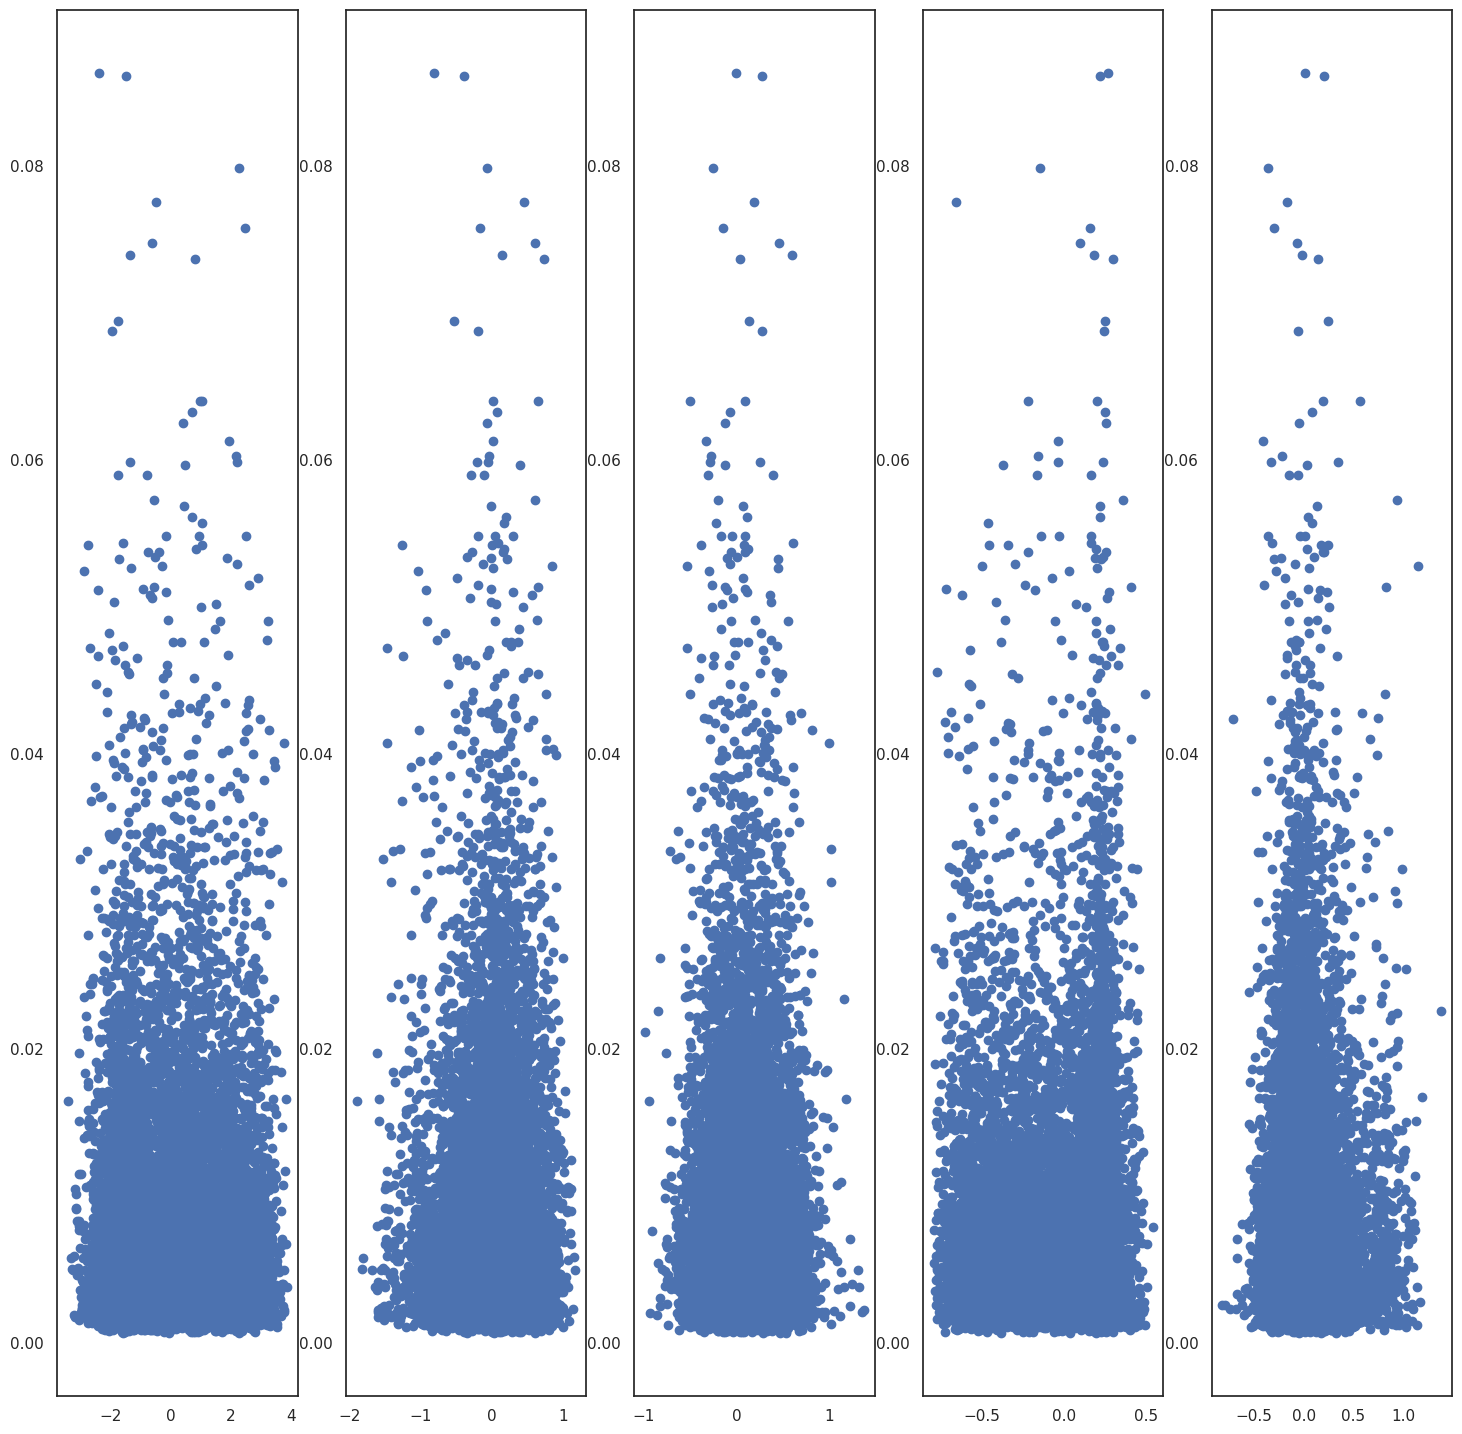

In [80]:
X_reduced.shape

X_reduced_mam = X_reduced[sample_size:]
X_reduced_son = X_reduced[:sample_size]

mam_mean = X_reduced_mam.mean(axis=0)
distance_from_mean = mam_mean - X_reduced_son

error = mam_trained_son_abs_error.mean(axis=1)[rnd]  

fig, axis = plt.subplots(1, 5, figsize=(18, 18))

for i in range(5):
    ax = axis[i]
    ax.scatter(distance_from_mean[:, i], error)

plt.show()


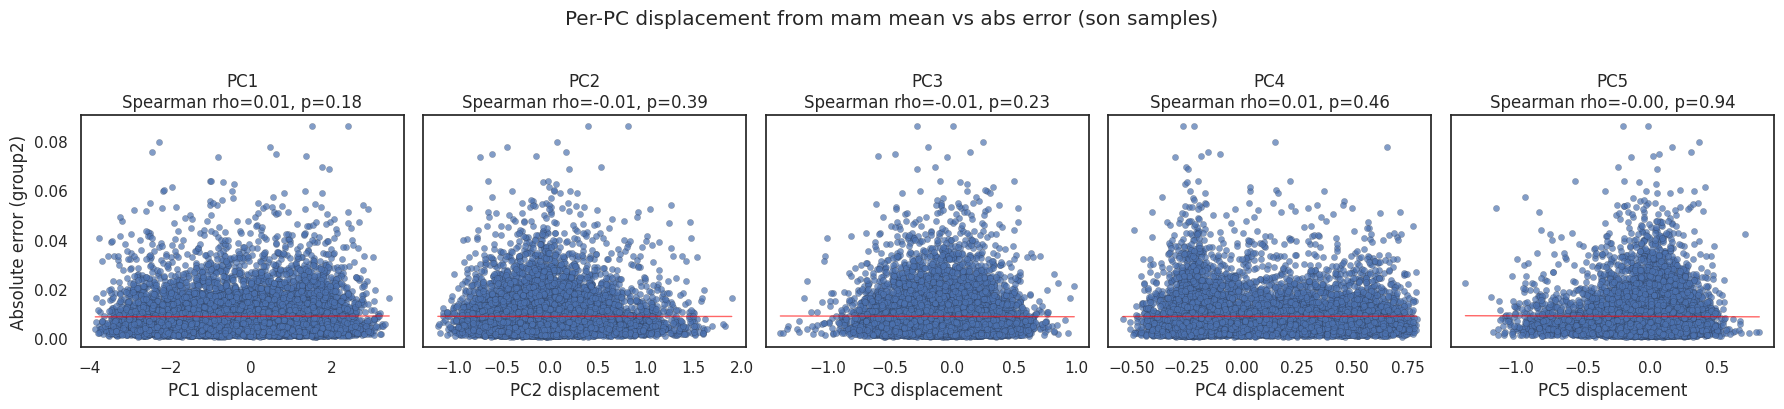

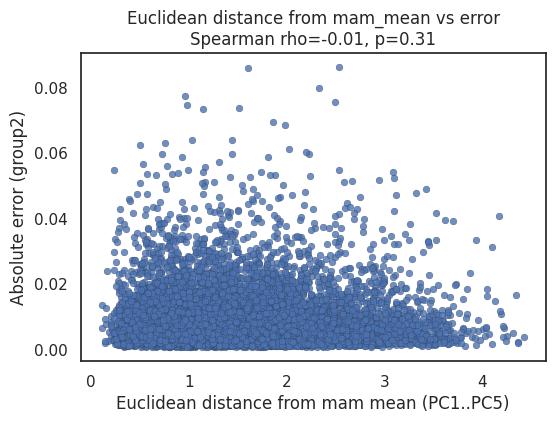

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ---- prepare arrays (your variables) ----
# X_reduced: (2*sample_size, 5)
# sample_size: int
# mam_trained_son_abs_error.mean(axis=1)[rnd] -> error: (sample_size,)

X_reduced = np.asarray(X_reduced)  # guard
assert X_reduced.ndim == 2 and X_reduced.shape[1] >= 5, "X_reduced must have at least 5 components"

# split
X_reduced_son = X_reduced[:sample_size]   # son = first sample_size
X_reduced_mam = X_reduced[sample_size:]   # mam = last sample_size

# compute mam mean in PCA space
mam_mean = X_reduced_mam.mean(axis=0)     # shape (n_components,)

# make sure error vector length matches sample_size
error = np.asarray(mam_trained_son_abs_error.mean(axis=1)[rnd])
assert error.shape[0] == sample_size, f"error length {error.shape[0]} != sample_size {sample_size}"

# compute per-component displacement of each son sample from the mam mean
# positive = son is larger along that PC than mam_mean
disp = X_reduced_son - mam_mean  # shape (sample_size, n_components)

# optionally take absolute displacement (magnitude)
abs_disp = np.abs(disp)

# Or compute overall Euclidean distance from mam_mean
euclid = np.linalg.norm(disp, axis=1)

# ---- plotting ----
n_comps = 5
fig, axes = plt.subplots(1, n_comps, figsize=(18, 4), sharey=True)
axes = np.asarray(axes).ravel()

for i, ax in enumerate(axes[:n_comps]):
    # scatter of signed displacement vs error
    ax.scatter(disp[:, i], error, s=20, alpha=0.7, edgecolor='k', linewidth=0.15)

    # optional: show absolute displacement as a second view (comment out if not desired)
    # ax.scatter(abs_disp[:, i], error, s=20, alpha=0.6, edgecolor='none', cmap='viridis')

    # add a simple linear fit line for visual aid
    m, b = np.polyfit(disp[:, i], error, 1)
    xs = np.linspace(disp[:, i].min(), disp[:, i].max(), 50)
    ax.plot(xs, m * xs + b, color='red', lw=1, alpha=0.6)

    # compute and display Spearman correlation (non-parametric)
    rho, pval = spearmanr(disp[:, i], error)
    ax.set_title(f'PC{i+1}\nSpearman rho={rho:.2f}, p={pval:.2g}')
    ax.set_xlabel(f'PC{i+1} displacement')
    if i == 0:
        ax.set_ylabel('Absolute error (group2)')

fig.suptitle('Per-PC displacement from mam mean vs abs error (son samples)', y=1.02)
plt.tight_layout()
plt.show()

# ---- additionally, plot Euclidean distance vs error ----
plt.figure(figsize=(6,4))
plt.scatter(euclid, error, s=25, alpha=0.8, edgecolor='k', linewidth=0.15)
rho, pval = spearmanr(euclid, error)
plt.title(f'Euclidean distance from mam_mean vs error\nSpearman rho={rho:.2f}, p={pval:.2g}')
plt.xlabel('Euclidean distance from mam mean (PC1..PC5)')
plt.ylabel('Absolute error (group2)')
plt.show()


/tmp/ipykernel_4011387/128974300.py:98: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



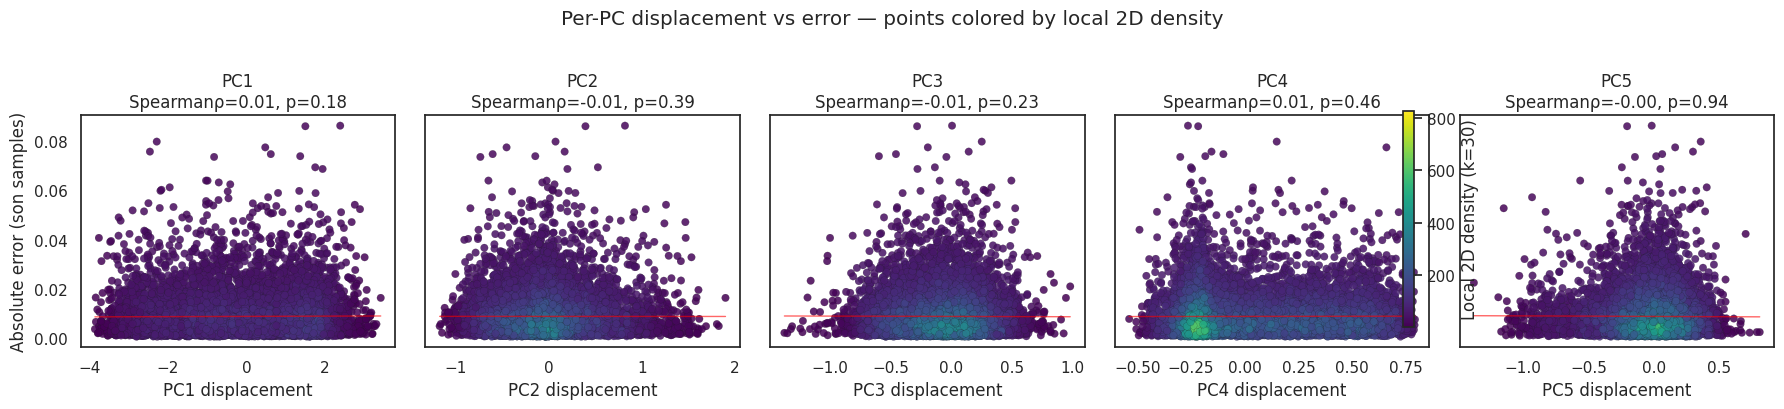

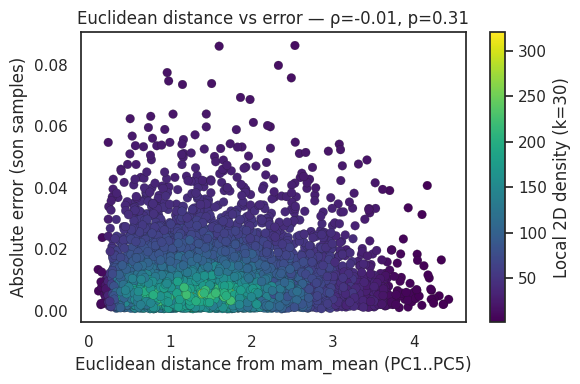

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from sklearn.neighbors import NearestNeighbors
from scipy.stats import spearmanr

def compute_2d_local_density(X2, n_neighbors=30):
    """
    Simple 2D local density estimate using distance to k-th nearest neighbor.
    X2: array-like shape (n_samples, 2)
    returns: density array shape (n_samples,) where larger => denser
    """
    X2 = np.asarray(X2)
    n_samples = X2.shape[0]
    k = int(min(n_neighbors, max(1, n_samples - 1)))
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X2)  # +1 to include the point itself
    distances, _ = nbrs.kneighbors(X2)  # shape (n_samples, k+1)
    d_k = distances[:, -1]               # distance to k-th neighbor
    eps = 1e-12
    density = 1.0 / (d_k + eps)
    return density

# ---- Prepare variables (guards + splits) ----
X_reduced = np.asarray(X_reduced)   # ensure ndarray
assert X_reduced.ndim == 2 and X_reduced.shape[1] >= 5, "X_reduced must be (N, >=5)"
assert X_reduced.shape[0] >= 2 * sample_size, "X_reduced length should be at least 2*sample_size"

# split son / mam
X_reduced_son = X_reduced[:sample_size]      # first sample_size: son
X_reduced_mam = X_reduced[sample_size:2*sample_size]  # last sample_size: mam (assumes exactly 2*sample_size)

# mam mean in PCA space
mam_mean = X_reduced_mam.mean(axis=0)        # shape (n_components,)

# error vector for son samples
error = np.asarray(mam_trained_son_abs_error.mean(axis=1)[rnd])
assert error.shape[0] == sample_size, f"error length {error.shape[0]} != sample_size {sample_size}"

# displacement of son samples from mam mean (signed)
disp = X_reduced_son - mam_mean              # shape (sample_size, n_components)
abs_disp = np.abs(disp)
euclid = np.linalg.norm(disp[:, :5], axis=1)  # Euclidean over first 5 components (if desired)

# ---- Set up plotting ----
n_comps = 5
fig, axes = plt.subplots(1, n_comps, figsize=(18, 4), sharey=True)
axes = np.asarray(axes).ravel()

# We will compute density per subplot (because each subplot uses different x-values),
# but we want one shared color scale: compute densities for all subplots and take min/max
all_densities = []
n_neighbors = 30

for i in range(n_comps):
    # 2D points for density estimation: (disp[:, i], error)
    xy = np.column_stack([disp[:, i], error])
    dens = compute_2d_local_density(xy, n_neighbors=n_neighbors)
    all_densities.append(dens)

all_densities = np.column_stack(all_densities)  # shape (n_samples, n_comps)
dens_min, dens_max = np.min(all_densities), np.max(all_densities)
norm = Normalize(vmin=dens_min, vmax=dens_max)
cmap = plt.cm.viridis

# ---- Plot each PC scatter colored by density ----
for i, ax in enumerate(axes[:n_comps]):
    dens = all_densities[:, i]
    sc = ax.scatter(
        disp[:, i], error,
        c=dens,
        cmap=cmap,
        norm=norm,
        s=30, alpha=0.85, edgecolor='k', linewidth=0.12
    )

    # trend line (for orientation)
    try:
        m, b = np.polyfit(disp[:, i], error, 1)
        xs = np.linspace(disp[:, i].min(), disp[:, i].max(), 100)
        ax.plot(xs, m * xs + b, color='red', lw=1, alpha=0.6)
    except np.linalg.LinAlgError:
        pass

    rho, pval = spearmanr(disp[:, i], error)
    ax.set_title(f'PC{i+1}\nSpearmanρ={rho:.2f}, p={pval:.2g}')
    ax.set_xlabel(f'PC{i+1} displacement')
    if i == 0:
        ax.set_ylabel('Absolute error (son samples)')

# shared colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=axes.tolist(), shrink=0.7, pad=0.02)
cbar.set_label(f'Local 2D density (k={n_neighbors})')

fig.suptitle('Per-PC displacement vs error — points colored by local 2D density', y=1.02)
plt.tight_layout()
plt.show()

# ---- Optional: Euclidean distance vs error colored by 1D density ----
dens_euc = compute_2d_local_density(np.column_stack([euclid, error]), n_neighbors=n_neighbors)
plt.figure(figsize=(6,4))
plt.scatter(euclid, error, c=dens_euc, cmap=cmap, s=40, edgecolor='k', linewidth=0.12)
rho, pval = spearmanr(euclid, error)
plt.title(f'Euclidean distance vs error — ρ={rho:.2f}, p={pval:.2g}')
plt.xlabel('Euclidean distance from mam_mean (PC1..PC5)')
plt.ylabel('Absolute error (son samples)')
plt.colorbar(label=f'Local 2D density (k={n_neighbors})')
plt.tight_layout()
plt.show()


So this is all basically saying within the PCA of the data, there is a. no real shift between data in those plots and b. the error doesnt looked linked to distance from the mean of those plots either - i.e its not that ood pca component values mean worse error ...

So then the question becomes is this true in the latent space as well? How can we look at the compositionality of the latent space in such a way that when we adjust the space we can still somehow compare? Well one thought is a PCA analysis. We take all the data, pass it through and store its latent representations as well and then apply a similar assesement 